# Laboratorio 1 - Aprendizaje de Máquina

**Docente:** María del Pilar Villamil  
**Integrantes:**
- Juan Eduardo Briceño - 202320095 (Sección 3)
- Santiago Alberto Quiroz - 202216453 (Sección 3)

---

## Objetivo

Desarrollar un modelo de **regresión lineal** para predecir el **CVD Risk Score** (riesgo cardiovascular) a partir de datos médicos de pacientes.

### Pipeline del proyecto:

1. **Preprocesamiento de datos**
   - Completitud (manejo de valores nulos)
   - Unicidad (eliminación de duplicados)
   - Normalización de variables categóricas
   - Feature engineering

2. **Modelado**
   - Linear Regression
   - Ridge Regression (L2)
   - Lasso Regression (L1)

3. **Evaluación**
   - Métricas: R², RMSE, MAE
   - Análisis de overfitting
   - Selección del mejor modelo


![BannerAA_Notebooks.png](attachment:497865ac-0f71-47b4-b7f8-3bd33c0e8c4d.png)


Laboratorio # 1 de Aprendiza de Maquina 
Este notebook estará compuesto de las siguientes partes:
1. Importar las librerías que usaremos.
2. Cargar el conjunto de datos.
3. Limpieza de datos.
4. Particion de los datos en entrenamiento y test.
5. Construcción de un pipeline de perparación de datos.
6. Entrenamiento del modelo de regresión lineal.
7. Estimación de la capacidad de generalización del modelo.
8. Verificación de los supuestos de la regresión lineal.s sector.

## 1. Importación de las librerías

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import linear_rainbow
from scipy.stats import ttest_1samp
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro

## 2. Carga de los datos

Para este notebook se usan los datos médicos e historial. Como primer paso se usará las funciones read_ usaremos la función de Pandas `read_csv()` debido a, como se trabajan los archivos (son csv). Los archivos será almacenado nuevamente en las variables `train` y 'test.

In [53]:
train = "./data/Datos Lab 1.csv"
test = "./data/Datos Test Lab 1.csv"
dicc = "./data/DiccPacientes.xlsx"

Además se procede a separar las presión sanguinea en sistolica y diastólica en 2 columnas distintas para el manejo de datos.

In [54]:
def separar_blood_pressure(df):
    """
    Separa la columna 'Blood Pressure (mmHg)' en Systolic BP y Diastolic BP.
    Formato esperado: "120/80"
    Si ya existen las columnas Systolic BP y Diastolic BP, las sobrescribe
    solo para las filas donde Blood Pressure (mmHg) tiene datos válidos.
    Parametros:
    - df: DataFrame con columna 'Blood Pressure (mmHg)'
    Retorna:
    - df: DataFrame con columnas 'Systolic BP Extracted' y 'Diastolic BP Extracted'
    """
    print("=" * 80)
    print("SEPARACION DE BLOOD PRESSURE")
    print("=" * 80)
    df_result = df.copy()
    if 'Blood Pressure (mmHg)' not in df.columns:
        print("\nAdvertencia: Columna 'Blood Pressure (mmHg)' no encontrada")
        return df_result
    if df['Blood Pressure (mmHg)'].dtype != 'object':
        print("\nLa columna 'Blood Pressure (mmHg)' ya es numérica, no se procesará")
        return df_result
    print(f"\nProcesando {len(df)} registros...")
    ejemplos = df['Blood Pressure (mmHg)'].dropna().head(10).tolist()
    print(f"\nEjemplos de valores originales:")
    for i, ejemplo in enumerate(ejemplos[:5], 1):
        print(f"  {i}. {ejemplo}")
    def extraer_presion(valor):
        if pd.isna(valor):
            return None, None
        valor_str = str(valor).strip()
        if '/' in valor_str:
            partes = valor_str.split('/')
            if len(partes) == 2:
                try:
                    sistolica = float(partes[0].strip())
                    diastolica = float(partes[1].strip())
                    return sistolica, diastolica
                except (ValueError, AttributeError):
                    return None, None
        return None, None
    resultados = df['Blood Pressure (mmHg)'].apply(extraer_presion)
    sistolicas = [r[0] if r else None for r in resultados]
    diastolicas = [r[1] if r else None for r in resultados]
    df_result['Systolic BP Extracted'] = sistolicas
    df_result['Diastolic BP Extracted'] = diastolicas
    valores_extraidos = sum([1 for s, d in zip(sistolicas, diastolicas) if s is not None and d is not None])
    valores_fallidos = len(df) - valores_extraidos - df['Blood Pressure (mmHg)'].isna().sum()
    print(f"\nResultados de la extracción:")
    print(f"  Valores extraídos exitosamente: {valores_extraidos}")
    print(f"  Valores nulos originales: {df['Blood Pressure (mmHg)'].isna().sum()}")
    print(f"  Valores que no pudieron extraerse: {valores_fallidos}")
    if valores_extraidos > 0:
        print(f"\nEstadísticas de Systolic BP Extracted:")
        sistolicas_validas = [s for s in sistolicas if s is not None]
        print(f"  Media: {np.mean(sistolicas_validas):.2f}")
        print(f"  Min: {np.min(sistolicas_validas):.2f}")
        print(f"  Max: {np.max(sistolicas_validas):.2f}")
        print(f"\nEstadísticas de Diastolic BP Extracted:")
        diastolicas_validas = [d for d in diastolicas if d is not None]
        print(f"  Media: {np.mean(diastolicas_validas):.2f}")
        print(f"  Min: {np.min(diastolicas_validas):.2f}")
        print(f"  Max: {np.max(diastolicas_validas):.2f}")
        if 'Systolic BP' in df.columns and 'Diastolic BP' in df.columns:
            print(f"\nComparación con columnas existentes:")
            df_temp = pd.DataFrame({
                'Systolic_Original': df['Systolic BP'],
                'Systolic_Extracted': sistolicas,
                'Diastolic_Original': df['Diastolic BP'],
                'Diastolic_Extracted': diastolicas
            })
            df_temp['Diff_Systolic'] = df_temp['Systolic_Original'] - df_temp['Systolic_Extracted']
            df_temp['Diff_Diastolic'] = df_temp['Diastolic_Original'] - df_temp['Diastolic_Extracted']
            coincidencias_sys = (df_temp['Diff_Systolic'].abs() < 0.01).sum()
            coincidencias_dia = (df_temp['Diff_Diastolic'].abs() < 0.01).sum()
            print(f"  Systolic BP coincide: {coincidencias_sys}/{len(df)}")
            print(f"  Diastolic BP coincide: {coincidencias_dia}/{len(df)}")
            if coincidencias_sys > valores_extraidos * 0.9 and coincidencias_dia > valores_extraidos * 0.9:
                print(f"\n  Las columnas extraídas coinciden con las existentes (>90%)")
                print(f"  Recomendación: Usar las columnas existentes Systolic BP y Diastolic BP")
            else:
                print(f"\n  Las columnas extraídas NO coinciden completamente")
                print(f"  Recomendación: Combinar información de ambas fuentes")
    print("\n" + "=" * 80)
    print("SEPARACION COMPLETADA")
    print("=" * 80)
    return df_result
def combinar_presiones_sanguineas(df):
    """
    Combina las columnas de presión sanguínea existentes con las extraídas.
    Estrategia:
    1. Si Systolic BP existe y no es nulo, usarlo
    2. Si no, usar Systolic BP Extracted
    3. Lo mismo para Diastolic BP
    """
    print("\n" + "=" * 80)
    print("COMBINACION DE COLUMNAS DE PRESION SANGUINEA")
    print("=" * 80)
    df_result = df.copy()
    tiene_systolic = 'Systolic BP' in df.columns
    tiene_diastolic = 'Diastolic BP' in df.columns
    tiene_systolic_ext = 'Systolic BP Extracted' in df.columns
    tiene_diastolic_ext = 'Diastolic BP Extracted' in df.columns
    print(f"\nColumnas disponibles:")
    print(f"  Systolic BP: {tiene_systolic}")
    print(f"  Diastolic BP: {tiene_diastolic}")
    print(f"  Systolic BP Extracted: {tiene_systolic_ext}")
    print(f"  Diastolic BP Extracted: {tiene_diastolic_ext}")
    if tiene_systolic and tiene_systolic_ext:
        df_result['Systolic BP Final'] = df['Systolic BP'].fillna(df['Systolic BP Extracted'])
        valores_originales = df['Systolic BP'].notna().sum()
        valores_rellenados = df_result['Systolic BP Final'].notna().sum() - valores_originales
        print(f"\nSystolic BP Final:")
        print(f"  Valores de columna original: {valores_originales}")
        print(f"  Valores rellenados con Extracted: {valores_rellenados}")
        print(f"  Total valores completos: {df_result['Systolic BP Final'].notna().sum()}")
    elif tiene_systolic:
        df_result['Systolic BP Final'] = df['Systolic BP']
        print(f"\nUsando solo Systolic BP (no hay Extracted)")
    elif tiene_systolic_ext:
        df_result['Systolic BP Final'] = df['Systolic BP Extracted']
        print(f"\nUsando solo Systolic BP Extracted (no hay original)")
    if tiene_diastolic and tiene_diastolic_ext:
        df_result['Diastolic BP Final'] = df['Diastolic BP'].fillna(df['Diastolic BP Extracted'])
        valores_originales = df['Diastolic BP'].notna().sum()
        valores_rellenados = df_result['Diastolic BP Final'].notna().sum() - valores_originales
        print(f"\nDiastolic BP Final:")
        print(f"  Valores de columna original: {valores_originales}")
        print(f"  Valores rellenados con Extracted: {valores_rellenados}")
        print(f"  Total valores completos: {df_result['Diastolic BP Final'].notna().sum()}")
    elif tiene_diastolic:
        df_result['Diastolic BP Final'] = df['Diastolic BP']
        print(f"\nUsando solo Diastolic BP (no hay Extracted)")
    elif tiene_diastolic_ext:
        df_result['Diastolic BP Final'] = df['Diastolic BP Extracted']
        print(f"\nUsando solo Diastolic BP Extracted (no hay original)")
    columnas_a_eliminar = ['Systolic BP', 'Diastolic BP', 
                           'Systolic BP Extracted', 'Diastolic BP Extracted',
                           'Blood Pressure (mmHg)']
    columnas_eliminadas = []
    for col in columnas_a_eliminar:
        if col in df_result.columns:
            df_result = df_result.drop(col, axis=1)
            columnas_eliminadas.append(col)
    if 'Systolic BP Final' in df_result.columns:
        df_result = df_result.rename(columns={'Systolic BP Final': 'Systolic BP'})
    if 'Diastolic BP Final' in df_result.columns:
        df_result = df_result.rename(columns={'Diastolic BP Final': 'Diastolic BP'})
    print(f"\nColumnas eliminadas: {columnas_eliminadas}")
    print(f"Columnas finales de presión: Systolic BP, Diastolic BP")
    print("\n" + "=" * 80)
    print("COMBINACION COMPLETADA")
    print("=" * 80)
    return df_result
# df_test = pd.read_csv(test, sep=";")

In [55]:
df_train = pd.read_csv(train)
df_test = pd.read_csv(test, sep=";")
print(df_train.describe())
print("cambio a df_test")
print(df_test.describe())
df_train = separar_blood_pressure(df_train)
df_test = separar_blood_pressure(df_test)

               Age  Weight (kg)   Height (m)          BMI  \
count  1571.000000  1566.000000  1578.000000  1586.000000   
mean     46.803186    85.666006     1.757439    28.424744   
std      13.039479    21.712504     0.118012     7.309275   
min       6.134000    13.261000     1.371000     4.317000   
25%      37.000000    67.100000     1.666500    22.600000   
50%      46.000000    86.314000     1.760000    28.000000   
75%      55.000000   104.801500     1.850000    33.963000   
max      89.420000   158.523000     2.146000    53.028000   

       Abdominal Circumference (cm)  Total Cholesterol (mg/dL)  HDL (mg/dL)  \
count                   1578.000000                1571.000000  1557.000000   
mean                      91.538861                 199.043673    56.183558   
std                       13.427985                  59.388670    16.721702   
min                       49.542000                  -1.256000     0.008000   
25%                       79.700000                 150

## 3. Limpieza inicial de datos.



### 3.1 Verificación de las dimensiones

Para la verificación de las 4 dimensiones (completitud, unicidad, consistencia y validez) se empieza a hacer un recorrido y conteo de los valores nulos con el fin de verificar la completitud.

#### Completitud

##### Completitud a partir de borrado de nulos en variable objetivo

In [56]:
# df_test = pd.read_csv(test, sep=";")
def verificar_completitud(df_train, df_test):
    """
    Verifica la completitud de los datasets y limpia valores nulos de CVD Risk Score
    """
    print("=" * 80)
    print("VERIFICACIÓN DE COMPLETITUD - ANÁLISIS INICIAL")
    print("=" * 80)
    print("\n DATASET DE ENTRENAMIENTO")
    print("-" * 80)
    print(f"Dimensiones: {df_train.shape[0]} filas × {df_train.shape[1]} columnas")
    print("\n🔍 Análisis de valores nulos por columna:\n")
    completitud_train = pd.DataFrame({
        'Columna': df_train.columns,
        'Total Filas': len(df_train),
        'Valores Completos': df_train.notna().sum(),
        'Valores Nulos': df_train.isnull().sum(),
        '% Nulos': (df_train.isnull().sum() / len(df_train) * 100).round(2),
        '% Completos': (df_train.notna().sum() / len(df_train) * 100).round(2)
    })
    print(completitud_train.to_string(index=False))
    total_valores = df_train.shape[0] * df_train.shape[1]
    valores_nulos = df_train.isnull().sum().sum()
    valores_completos = total_valores - valores_nulos
    print("\n" + "-" * 80)
    print("RESUMEN DE COMPLETITUD:")
    print(f"  • Total de valores en el dataset: {total_valores:,}")
    print(f"  • Valores completos: {valores_completos:,} ({(valores_completos/total_valores*100):.2f}%)")
    print(f"  • Valores nulos: {valores_nulos:,} ({(valores_nulos/total_valores*100):.2f}%)")
    cols_con_nulos = completitud_train[completitud_train['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False)
    if len(cols_con_nulos) > 0:
        print(f"\n⚠️  Columnas con valores nulos: {len(cols_con_nulos)}")
        print("\nTop 5 columnas con más valores nulos:")
        print(cols_con_nulos.head()[['Columna', 'Valores Nulos', '% Nulos']].to_string(index=False))
    else:
        print("\n✅ ¡No hay valores nulos en ninguna columna!")
    print("\n" + "=" * 80)
    print(" VARIABLE OBJETIVO: CVD Risk Score")
    print("=" * 80)
    cvd_nulos_antes = df_train['CVD Risk Score'].isnull().sum()
    cvd_completos_antes = df_train['CVD Risk Score'].notna().sum()
    print(f"\nEstado ANTES de limpiar:")
    print(f"  • Valores completos: {cvd_completos_antes} ({(cvd_completos_antes/len(df_train)*100):.2f}%)")
    print(f"  • Valores nulos: {cvd_nulos_antes} ({(cvd_nulos_antes/len(df_train)*100):.2f}%)")
    if cvd_nulos_antes > 0:
        print(f"\n⚠️  Se encontraron {cvd_nulos_antes} filas con CVD Risk Score nulo")
    else:
        print("\n✅ No hay valores nulos en CVD Risk Score")
    print("\n" + "=" * 80)
    print("🧹 LIMPIEZA DE VALORES NULOS EN CVD Risk Score")
    print("=" * 80)
    filas_antes = len(df_train)
    df_train_limpio = df_train.dropna(subset=['CVD Risk Score']).copy()
    filas_despues = len(df_train_limpio)
    filas_eliminadas = filas_antes - filas_despues
    print(f"\n📊 Resultado de la limpieza:")
    print(f"  • Filas ANTES: {filas_antes}")
    print(f"  • Filas DESPUÉS: {filas_despues}")
    print(f"  • Filas eliminadas: {filas_eliminadas}")
    if filas_eliminadas > 0:
        print(f"\n✅ Se eliminaron {filas_eliminadas} filas ({(filas_eliminadas/filas_antes*100):.2f}%)")
    else:
        print("\n✅ No se eliminaron filas (no había valores nulos)")
    cvd_nulos_despues = df_train_limpio['CVD Risk Score'].isnull().sum()
    print(f"\nVerificación DESPUÉS de limpiar:")
    print(f"  • Valores nulos en CVD Risk Score: {cvd_nulos_despues} ✅")
    print("\n" + "=" * 80)
    print("📊 DATASET DE PRUEBA")
    print("=" * 80)
    print(f"\nDimensiones: {df_test.shape[0]} filas × {df_test.shape[1]} columnas")
    print("\n🔍 Análisis de valores nulos por columna:\n")
    completitud_test = pd.DataFrame({
        'Columna': df_test.columns,
        'Total Filas': len(df_test),
        'Valores Completos': df_test.notna().sum(),
        'Valores Nulos': df_test.isnull().sum(),
        '% Nulos': (df_test.isnull().sum() / len(df_test) * 100).round(2),
        '% Completos': (df_test.notna().sum() / len(df_test) * 100).round(2)
    })
    print(completitud_test.to_string(index=False))
    total_valores_test = df_test.shape[0] * df_test.shape[1]
    valores_nulos_test = df_test.isnull().sum().sum()
    valores_completos_test = total_valores_test - valores_nulos_test
    print("\n" + "-" * 80)
    print("📈 RESUMEN DE COMPLETITUD:")
    print(f"  • Total de valores en el dataset: {total_valores_test:,}")
    print(f"  • Valores completos: {valores_completos_test:,} ({(valores_completos_test/total_valores_test*100):.2f}%)")
    print(f"  • Valores nulos: {valores_nulos_test:,} ({(valores_nulos_test/total_valores_test*100):.2f}%)")
    cols_con_nulos_test = completitud_test[completitud_test['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False)
    if len(cols_con_nulos_test) > 0:
        print(f"\n⚠️  Columnas con valores nulos: {len(cols_con_nulos_test)}")
        print("\nColumnas con valores nulos:")
        print(cols_con_nulos_test[['Columna', 'Valores Nulos', '% Nulos']].to_string(index=False))
    else:
        print("\n✅ ¡No hay valores nulos en ninguna columna!")
    print("\n" + "=" * 80)
    print("📊 RESUMEN FINAL COMPARATIVO")
    print("=" * 80)
    resumen = pd.DataFrame({
        'Dataset': ['Train (Original)', 'Train (Limpio)', 'Test'],
        'Filas': [filas_antes, filas_despues, df_test.shape[0]],
        'Columnas': [df_train.shape[1], df_train_limpio.shape[1], df_test.shape[1]],
        'Total Valores': [
            filas_antes * df_train.shape[1],
            filas_despues * df_train_limpio.shape[1],
            df_test.shape[0] * df_test.shape[1]
        ],
        'Valores Nulos': [
            df_train.isnull().sum().sum(),
            df_train_limpio.isnull().sum().sum(),
            df_test.isnull().sum().sum()
        ]
    })
    resumen['% Completitud'] = ((resumen['Total Valores'] - resumen['Valores Nulos']) / 
                                 resumen['Total Valores'] * 100).round(2)
    print("\n" + resumen.to_string(index=False))
    print("\n" + "=" * 80)
    print("✅ VERIFICACIÓN DE COMPLETITUD FINALIZADA")
    print("=" * 80)
    return df_train_limpio
df_train_limpio = verificar_completitud(df_train, df_test)
df_train_limpio.describe()

VERIFICACIÓN DE COMPLETITUD - ANÁLISIS INICIAL

 DATASET DE ENTRENAMIENTO
--------------------------------------------------------------------------------
Dimensiones: 1639 filas × 26 columnas

🔍 Análisis de valores nulos por columna:

                     Columna  Total Filas  Valores Completos  Valores Nulos  % Nulos  % Completos
                  Patient ID         1639               1639              0     0.00       100.00
             Date of Service         1639               1639              0     0.00       100.00
                         Sex         1639               1639              0     0.00       100.00
                         Age         1639               1571             68     4.15        95.85
                 Weight (kg)         1639               1566             73     4.45        95.55
                  Height (m)         1639               1578             61     3.72        96.28
                         BMI         1639               1586             53   

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score,Systolic BP Extracted,Diastolic BP Extracted
count,1543.000000,1538.000000,1550.000000,1559.000000,1551.000000,1542.000000,1528.000000,1557.000000,1542.000000,1534.000000,1550.000000,1527.000000,1553.000000,1610.000000,1610.000000,1610.000000
mean,46.769697,85.880566,1.757666,28.472249,91.557663,198.971213,56.164136,117.894299,175.737219,0.522502,125.744710,82.878344,113.190076,18.227281,125.674534,83.071429
std,12.982762,21.713386,0.118354,7.308841,13.432154,59.422174,16.706169,32.401372,11.666975,0.085794,22.592423,15.532337,61.473080,10.767666,21.924605,14.676728
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000,90.000000,60.000000
25%,37.000000,67.300000,1.668500,22.680500,79.700000,150.000000,42.000000,92.000000,167.000000,0.453000,108.000000,71.000000,62.000000,15.150000,108.000000,71.000000
50%,46.000000,86.500000,1.760000,28.038000,91.200000,198.000000,56.000000,115.000000,176.000000,0.519000,125.000000,82.000000,112.000000,16.967000,125.000000,82.000000
75%,55.000000,105.100000,1.850000,34.004500,102.262500,250.000000,70.000000,139.000000,185.000000,0.582000,141.000000,93.000000,159.000000,18.900000,141.000000,93.000000
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000,179.000000,119.000000


##### Completitud a partir de imputación. ( % De datos con null cercanos al 5%)

Debido a que los datos nulos no pasaban la métrica del 5% se decide aplicarles una imputación para un mejor análisis, se decide además reemplazarlos por la medía a través     de df_train_imputado[col].fillna(media, inplace=True).

In [57]:
def imputar_valores_nulos_con_media(df_train_limpio, df_test):
    """
    Imputa valores nulos con la media para columnas numéricas.
    Parámetros:
    - df_train_limpio: DataFrame de entrenamiento ya limpio (sin nulos en CVD Risk Score)
    - df_test: DataFrame de prueba
    Retorna:
    - df_train_imputado: DataFrame de entrenamiento con valores imputados
    - df_test_imputado: DataFrame de prueba con valores imputados
    - reporte_imputacion: Diccionario con información de la imputación
    """
    print("=" * 80)
    print(" IMPUTACIÓN DE VALORES NULOS CON LA MEDIA")
    print("=" * 80)
    df_train_imputado = df_train_limpio.copy()
    df_test_imputado = df_test.copy()
    print("\n DATASET DE ENTRENAMIENTO - Análisis previo")
    print("-" * 80)
    columnas_numericas = df_train_imputado.select_dtypes(include=[np.number]).columns.tolist()
    if 'CVD Risk Score' in columnas_numericas:
        columnas_numericas.remove('CVD Risk Score')
    print(f"\nColumnas numéricas a evaluar: {len(columnas_numericas)}")
    cols_con_nulos_train = []
    info_imputacion_train = {}
    for col in columnas_numericas:
        nulos = df_train_imputado[col].isnull().sum()
        if nulos > 0:
            cols_con_nulos_train.append(col)
            media = df_train_imputado[col].mean()
            pct_nulos = (nulos / len(df_train_imputado)) * 100
            info_imputacion_train[col] = {
                'nulos': nulos,
                'porcentaje': pct_nulos,
                'media': media
            }
    if cols_con_nulos_train:
        print(f"\n  Se encontraron {len(cols_con_nulos_train)} columnas con valores nulos:\n")
        tabla_nulos_train = pd.DataFrame({
            'Columna': cols_con_nulos_train,
            'Valores Nulos': [info_imputacion_train[col]['nulos'] for col in cols_con_nulos_train],
            '% Nulos': [f"{info_imputacion_train[col]['porcentaje']:.2f}%" for col in cols_con_nulos_train],
            'Media': [f"{info_imputacion_train[col]['media']:.4f}" for col in cols_con_nulos_train]
        })
        print(tabla_nulos_train.to_string(index=False))
    else:
        print("\n No hay valores nulos en columnas numéricas del dataset de entrenamiento")
    print("\n" + "=" * 80)
    print(" IMPUTANDO VALORES EN DATASET DE ENTRENAMIENTO")
    print("=" * 80)
    valores_imputados_train = 0
    if cols_con_nulos_train:
        for col in cols_con_nulos_train:
            nulos_antes = df_train_imputado[col].isnull().sum()
            media = info_imputacion_train[col]['media']
            df_train_imputado[col].fillna(media, inplace=True)
            nulos_despues = df_train_imputado[col].isnull().sum()
            valores_imputados = nulos_antes - nulos_despues
            valores_imputados_train += valores_imputados
            print(f"✓ {col:40s} | Imputados: {valores_imputados:4d} | Media: {media:10.4f}")
        print(f"\n Total de valores imputados: {valores_imputados_train}")
    else:
        print("\n No se necesitó imputar ningún valor")
    nulos_restantes_train = df_train_imputado[columnas_numericas].isnull().sum().sum()
    print(f"\n Verificación: Valores nulos restantes en columnas numéricas: {nulos_restantes_train}")
    print("\n" + "=" * 80)
    print(" DATASET DE PRUEBA - Análisis previo")
    print("=" * 80)
    columnas_numericas_test = df_test_imputado.select_dtypes(include=[np.number]).columns.tolist()
    print(f"\nColumnas numéricas a evaluar: {len(columnas_numericas_test)}")
    cols_con_nulos_test = []
    info_imputacion_test = {}
    for col in columnas_numericas_test:
        nulos = df_test_imputado[col].isnull().sum()
        if nulos > 0:
            cols_con_nulos_test.append(col)
            if col in info_imputacion_train:
                media = info_imputacion_train[col]['media']
            else:
                media = df_train_imputado[col].mean()
            pct_nulos = (nulos / len(df_test_imputado)) * 100
            info_imputacion_test[col] = {
                'nulos': nulos,
                'porcentaje': pct_nulos,
                'media': media
            }
    if cols_con_nulos_test:
        print(f"\n  Se encontraron {len(cols_con_nulos_test)} columnas con valores nulos:\n")
        tabla_nulos_test = pd.DataFrame({
            'Columna': cols_con_nulos_test,
            'Valores Nulos': [info_imputacion_test[col]['nulos'] for col in cols_con_nulos_test],
            '% Nulos': [f"{info_imputacion_test[col]['porcentaje']:.2f}%" for col in cols_con_nulos_test],
            'Media (de Train)': [f"{info_imputacion_test[col]['media']:.4f}" for col in cols_con_nulos_test]
        })
        print(tabla_nulos_test.to_string(index=False))
    else:
        print("\n No hay valores nulos en columnas numéricas del dataset de prueba")
    print("\n" + "=" * 80)
    print(" IMPUTANDO VALORES EN DATASET DE PRUEBA")
    print("=" * 80)
    valores_imputados_test = 0
    if cols_con_nulos_test:
        for col in cols_con_nulos_test:
            nulos_antes = df_test_imputado[col].isnull().sum()
            media = info_imputacion_test[col]['media']
            df_test_imputado[col].fillna(media, inplace=True)
            nulos_despues = df_test_imputado[col].isnull().sum()
            valores_imputados = nulos_antes - nulos_despues
            valores_imputados_test += valores_imputados
            print(f"✓ {col:40s} | Imputados: {valores_imputados:4d} | Media: {media:10.4f}")
        print(f"\n Total de valores imputados: {valores_imputados_test}")
    else:
        print("\n No se necesitó imputar ningún valor")
    nulos_restantes_test = df_test_imputado[columnas_numericas_test].isnull().sum().sum()
    print(f"\n Verificación: Valores nulos restantes en columnas numéricas: {nulos_restantes_test}")
    print("\n" + "=" * 80)
    print(" RESUMEN FINAL DE IMPUTACIÓN")
    print("=" * 80)
    print(f"\n DATASET DE ENTRENAMIENTO:")
    print(f"  • Columnas con valores nulos imputados: {len(cols_con_nulos_train)}")
    print(f"  • Total de valores imputados: {valores_imputados_train}")
    print(f"  • Valores nulos restantes (columnas numéricas): {nulos_restantes_train}")
    print(f"\n DATASET DE PRUEBA:")
    print(f"  • Columnas con valores nulos imputados: {len(cols_con_nulos_test)}")
    print(f"  • Total de valores imputados: {valores_imputados_test}")
    print(f"  • Valores nulos restantes (columnas numéricas): {nulos_restantes_test}")
    nulos_no_numericos_train = df_train_imputado.select_dtypes(exclude=[np.number]).isnull().sum().sum()
    nulos_no_numericos_test = df_test_imputado.select_dtypes(exclude=[np.number]).isnull().sum().sum()
    if nulos_no_numericos_train > 0 or nulos_no_numericos_test > 0:
        print(f"\n  NOTA: Aún quedan valores nulos en columnas NO numéricas:")
        print(f"  • Train: {nulos_no_numericos_train} valores nulos")
        print(f"  • Test: {nulos_no_numericos_test} valores nulos")
        print(f"  • Estas columnas categóricas pueden necesitar imputación manual")
    print("\n" + "=" * 80)
    print("IMPUTACIÓN COMPLETADA")
    print("=" * 80)
    reporte_imputacion = {
        'train': {
            'columnas_imputadas': cols_con_nulos_train,
            'valores_imputados': valores_imputados_train,
            'info_columnas': info_imputacion_train
        },
        'test': {
            'columnas_imputadas': cols_con_nulos_test,
            'valores_imputados': valores_imputados_test,
            'info_columnas': info_imputacion_test
        }
    }
    return df_train_imputado, df_test_imputado, reporte_imputacion
df_train_final, df_test_final, reporte = imputar_valores_nulos_con_media(df_train_limpio, df_test)
df_train_final.describe()

 IMPUTACIÓN DE VALORES NULOS CON LA MEDIA

 DATASET DE ENTRENAMIENTO - Análisis previo
--------------------------------------------------------------------------------

Columnas numéricas a evaluar: 15

  Se encontraron 13 columnas con valores nulos:

                     Columna  Valores Nulos % Nulos    Media
                         Age             67   4.16%  46.7697
                 Weight (kg)             72   4.47%  85.8806
                  Height (m)             60   3.73%   1.7577
                         BMI             51   3.17%  28.4722
Abdominal Circumference (cm)             59   3.66%  91.5577
   Total Cholesterol (mg/dL)             68   4.22% 198.9712
                 HDL (mg/dL)             82   5.09%  56.1641
 Fasting Blood Sugar (mg/dL)             53   3.29% 117.8943
                 Height (cm)             68   4.22% 175.7372
       Waist-to-Height Ratio             76   4.72%   0.5225
                 Systolic BP             60   3.73% 125.7447
                

C:\Users\Santiago\AppData\Local\Temp\ipykernel_16176\3530703143.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train_imputado[col].fillna(media, inplace=True)
C:\Users\Santiago\AppData\Local\Temp\ipykernel_16176\3530703143.py:105: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Estimated LDL (mg/dL),CVD Risk Score,Systolic BP Extracted,Diastolic BP Extracted
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,46.769697,85.880566,1.757666,28.472249,91.557663,198.971213,56.164136,117.894299,175.737219,0.522502,125.744710,82.878344,113.190076,18.227281,125.674534,83.071429
std,12.709582,21.222007,0.116126,7.192075,13.183584,58.152961,16.274902,31.863258,11.417777,0.083743,22.167182,15.126416,60.374398,10.767666,21.924605,14.676728
min,6.134000,13.261000,1.371000,4.317000,49.542000,-1.256000,0.008000,15.306000,136.498000,0.250000,49.914000,31.720000,-92.055000,-20.057000,90.000000,60.000000
25%,37.000000,68.169250,1.670000,22.800000,80.100000,152.000000,43.000000,93.000000,167.000000,0.456000,109.000000,71.000000,63.000000,15.150000,108.000000,71.000000
50%,46.769697,85.880566,1.757666,28.472249,91.557663,198.971213,56.164136,117.000000,175.737219,0.522502,125.744710,82.878344,113.190076,16.967000,125.000000,82.000000
75%,55.000000,104.200000,1.843500,33.800000,101.700000,248.000000,69.000000,138.000000,184.057500,0.579000,141.000000,93.000000,157.750000,18.900000,141.000000,93.000000
max,89.420000,158.523000,2.146000,53.028000,136.336000,385.679000,110.315000,219.667000,214.394000,0.804000,202.711000,134.066000,317.314000,114.980000,179.000000,119.000000


#### Unicidad y Consistencia

Ahora para verificar la segunda y tercera dimensión (se sabe que se borraron ya los datos nulos y con ID repetida y es parte de unicidad) entonces se procede a comparar los datos para llevarlos al mismo formato. Adicionalmente, se busca encontrar a los datos duplicados si es igual se procede a borrar el mas viejo y para la verificación se unifica el formato de fecha.

In [58]:
import pandas as pd
import numpy as np
import random
import string
from datetime import datetime
def generar_id_aleatorio():
    """
    Genera un ID aleatorio con el formato de los datos existentes.
    Formato: 4 letras + 4 dígitos (ej: WYTG8678, yloc1993, DDwq7653)
    """
    letras = ''.join(random.choices(string.ascii_letters, k=4))
    numeros = ''.join(random.choices(string.digits, k=4))
    return letras + numeros
def parsear_fecha(fecha_str):
    """
    Intenta parsear diferentes formatos de fecha y retorna un objeto datetime.
    Retorna None si no puede parsear la fecha.
    """
    if pd.isna(fecha_str):
        return None
    formatos = [
        '%Y-%m-%d',           # 2024-01-15
        '%d/%m/%Y',           # 15/01/2024
        '%m/%d/%Y',           # 01/15/2024
        '%d-%m-%Y',           # 15-01-2024
        '%Y/%m/%d',           # 2024/01/15
        '%d.%m.%Y',           # 15.01.2024
        '%Y-%m-%d %H:%M:%S',  # 2024-01-15 10:30:00
        '%d/%m/%Y %H:%M:%S',  # 15/01/2024 10:30:00
    ]
    for formato in formatos:
        try:
            return datetime.strptime(str(fecha_str), formato)
        except (ValueError, TypeError):
            continue
    try:
        return pd.to_datetime(fecha_str)
    except:
        return None
def verificar_y_corregir_unicidad(df_train, df_test):
    """
    Verifica y corrige problemas de unicidad en los datasets.
    1. Formatea las fechas en 'Date of Service'
    2. Elimina duplicados completos (mismo ID y datos iguales), mantiene el más reciente
    3. Asigna nuevo ID a registros con ID repetido pero datos diferentes
    4. Verifica otros tipos de duplicados que puedan afectar el análisis
    Parametros:
    - df_train: DataFrame de entrenamiento
    - df_test: DataFrame de prueba
    Retorna:
    - df_train_unico: DataFrame de entrenamiento con unicidad corregida
    - df_test_unico: DataFrame de prueba con unicidad corregida
    - reporte_unicidad: Diccionario con información del proceso
    """
    print("=" * 80)
    print("VERIFICACION Y CORRECCION DE UNICIDAD")
    print("=" * 80)
    df_train_unico = df_train.copy()
    df_test_unico = df_test.copy()
    reporte_unicidad = {
        'train': {},
        'test': {}
    }
    print("\nPASO 1: FORMATEO DE FECHAS")
    print("-" * 80)
    for nombre_df, df in [('TRAIN', df_train_unico), ('TEST', df_test_unico)]:
        print(f"\nDataset: {nombre_df}")
        if 'Date of Service' not in df.columns:
            print("  Advertencia: Columna 'Date of Service' no encontrada")
            continue
        print(f"  Ejemplos de fechas originales:")
        fechas_muestra = df['Date of Service'].dropna().head(5).tolist()
        for i, fecha in enumerate(fechas_muestra, 1):
            print(f"    {i}. {fecha}")
        fechas_parseadas = df['Date of Service'].apply(parsear_fecha)
        fechas_validas = fechas_parseadas.notna().sum()
        fechas_invalidas = fechas_parseadas.isna().sum()
        print(f"\n  Resultado del parseo:")
        print(f"    Fechas validas: {fechas_validas}")
        print(f"    Fechas invalidas: {fechas_invalidas}")
        df['Date of Service Parsed'] = fechas_parseadas
        if fechas_validas > 0:
            print(f"\n  Ejemplos de fechas parseadas:")
            fechas_parseadas_muestra = fechas_parseadas.dropna().head(5).tolist()
            for i, fecha in enumerate(fechas_parseadas_muestra, 1):
                print(f"    {i}. {fecha}")
    print("\n" + "=" * 80)
    print("PASO 2: ANALISIS DE DUPLICADOS POR PATIENT ID")
    print("=" * 80)
    for nombre_df, df in [('TRAIN', df_train_unico), ('TEST', df_test_unico)]:
        print(f"\n--- Dataset: {nombre_df} ---")
        if 'Patient ID' not in df.columns:
            print("  Advertencia: Columna 'Patient ID' no encontrada")
            continue
        total_registros = len(df)
        ids_unicos = df['Patient ID'].nunique()
        ids_duplicados = df['Patient ID'].duplicated().sum()
        print(f"\nEstadisticas basicas:")
        print(f"  Total de registros: {total_registros}")
        print(f"  IDs unicos: {ids_unicos}")
        print(f"  Registros con ID duplicado: {ids_duplicados}")
        if ids_duplicados > 0:
            ids_repetidos = df[df['Patient ID'].duplicated(keep=False)]['Patient ID'].unique()
            print(f"  Numero de IDs que se repiten: {len(ids_repetidos)}")
            print(f"\n  Ejemplos de IDs duplicados:")
            for patient_id in ids_repetidos[:5]:
                count = (df['Patient ID'] == patient_id).sum()
                print(f"    {patient_id}: aparece {count} veces")
        else:
            print("\n  No se encontraron IDs duplicados")
    print("\n" + "=" * 80)
    print("PASO 3: PROCESAMIENTO DE DUPLICADOS - TRAIN")
    print("=" * 80)
    if 'Patient ID' in df_train_unico.columns:
        ids_duplicados_train = df_train_unico[df_train_unico['Patient ID'].duplicated(keep=False)]
        if len(ids_duplicados_train) > 0:
            print(f"\nSe encontraron {len(ids_duplicados_train)} registros con IDs duplicados")
            grupos_duplicados = ids_duplicados_train.groupby('Patient ID')
            registros_eliminados = 0
            ids_reasignados = 0
            ids_procesados = set()
            for patient_id, grupo in grupos_duplicados:
                if patient_id in ids_procesados:
                    continue
                indices = grupo.index.tolist()
                if len(indices) < 2:
                    continue
                registros = df_train_unico.loc[indices]
                columnas_comparar = [col for col in registros.columns 
                                   if col not in ['Patient ID', 'Date of Service', 'Date of Service Parsed']]
                primer_registro = registros.iloc[0][columnas_comparar]
                son_identicos = True
                for idx in range(1, len(registros)):
                    if not registros.iloc[idx][columnas_comparar].equals(primer_registro):
                        son_identicos = False
                        break
                if son_identicos:
                    if 'Date of Service Parsed' in registros.columns:
                        registros_ordenados = registros.sort_values('Date of Service Parsed', 
                                                                    ascending=False, 
                                                                    na_position='last')
                        indices_eliminar = registros_ordenados.index[1:].tolist()
                        df_train_unico = df_train_unico.drop(indices_eliminar)
                        registros_eliminados += len(indices_eliminar)
                    else:
                        indices_eliminar = indices[1:]
                        df_train_unico = df_train_unico.drop(indices_eliminar)
                        registros_eliminados += len(indices_eliminar)
                else:
                    for idx in indices[1:]:
                        nuevo_id = generar_id_aleatorio()
                        while nuevo_id in df_train_unico['Patient ID'].values:
                            nuevo_id = generar_id_aleatorio()
                        df_train_unico.at[idx, 'Patient ID'] = nuevo_id
                        ids_reasignados += 1
                ids_procesados.add(patient_id)
            print(f"\nResultados del procesamiento:")
            print(f"  Registros eliminados (duplicados identicos): {registros_eliminados}")
            print(f"  IDs reasignados (mismo ID, datos diferentes): {ids_reasignados}")
            reporte_unicidad['train']['registros_eliminados'] = registros_eliminados
            reporte_unicidad['train']['ids_reasignados'] = ids_reasignados
        else:
            print("\nNo se encontraron IDs duplicados en TRAIN")
            reporte_unicidad['train']['registros_eliminados'] = 0
            reporte_unicidad['train']['ids_reasignados'] = 0
    print("\n" + "=" * 80)
    print("PASO 4: PROCESAMIENTO DE DUPLICADOS - TEST")
    print("=" * 80)
    if 'Patient ID' in df_test_unico.columns:
        ids_duplicados_test = df_test_unico[df_test_unico['Patient ID'].duplicated(keep=False)]
        if len(ids_duplicados_test) > 0:
            print(f"\nSe encontraron {len(ids_duplicados_test)} registros con IDs duplicados")
            grupos_duplicados = ids_duplicados_test.groupby('Patient ID')
            registros_eliminados = 0
            ids_reasignados = 0
            ids_procesados = set()
            for patient_id, grupo in grupos_duplicados:
                if patient_id in ids_procesados:
                    continue
                indices = grupo.index.tolist()
                if len(indices) < 2:
                    continue
                registros = df_test_unico.loc[indices]
                columnas_comparar = [col for col in registros.columns 
                                   if col not in ['Patient ID', 'Date of Service', 'Date of Service Parsed']]
                primer_registro = registros.iloc[0][columnas_comparar]
                son_identicos = True
                for idx in range(1, len(registros)):
                    if not registros.iloc[idx][columnas_comparar].equals(primer_registro):
                        son_identicos = False
                        break
                if son_identicos:
                    if 'Date of Service Parsed' in registros.columns:
                        registros_ordenados = registros.sort_values('Date of Service Parsed', 
                                                                    ascending=False, 
                                                                    na_position='last')
                        indices_eliminar = registros_ordenados.index[1:].tolist()
                        df_test_unico = df_test_unico.drop(indices_eliminar)
                        registros_eliminados += len(indices_eliminar)
                    else:
                        indices_eliminar = indices[1:]
                        df_test_unico = df_test_unico.drop(indices_eliminar)
                        registros_eliminados += len(indices_eliminar)
                else:
                    for idx in indices[1:]:
                        nuevo_id = generar_id_aleatorio()
                        while nuevo_id in df_test_unico['Patient ID'].values:
                            nuevo_id = generar_id_aleatorio()
                        df_test_unico.at[idx, 'Patient ID'] = nuevo_id
                        ids_reasignados += 1
                ids_procesados.add(patient_id)
            print(f"\nResultados del procesamiento:")
            print(f"  Registros eliminados (duplicados identicos): {registros_eliminados}")
            print(f"  IDs reasignados (mismo ID, datos diferentes): {ids_reasignados}")
            reporte_unicidad['test']['registros_eliminados'] = registros_eliminados
            reporte_unicidad['test']['ids_reasignados'] = ids_reasignados
        else:
            print("\nNo se encontraron IDs duplicados en TEST")
            reporte_unicidad['test']['registros_eliminados'] = 0
            reporte_unicidad['test']['ids_reasignados'] = 0
    print("\n" + "=" * 80)
    print("PASO 5: VERIFICACION DE OTROS TIPOS DE DUPLICADOS")
    print("=" * 80)
    for nombre_df, df in [('TRAIN', df_train_unico), ('TEST', df_test_unico)]:
        print(f"\n--- Dataset: {nombre_df} ---")
        duplicados_completos = df.duplicated().sum()
        print(f"\nDuplicados completos (todas las columnas): {duplicados_completos}")
        if duplicados_completos > 0:
            print("  Advertencia: Se encontraron registros completamente duplicados")
            print("  Estos pueden afectar el analisis y deberian ser eliminados")
        columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
        if len(columnas_numericas) > 3:
            cols_verificar = [col for col in columnas_numericas 
                            if 'ID' not in col and 'Date' not in col][:5]
            if cols_verificar:
                duplicados_subset = df.duplicated(subset=cols_verificar).sum()
                print(f"\nDuplicados en columnas clave {cols_verificar[:3]}...: {duplicados_subset}")
                if duplicados_subset > 0:
                    print(f"  Nota: {duplicados_subset} registros tienen valores identicos en columnas clave")
                    print("  Esto puede ser normal en datos medicos, pero verificar si es esperado")
    print("\n" + "=" * 80)
    print("RESUMEN FINAL DE UNICIDAD")
    print("=" * 80)
    print("\nDATASET DE ENTRENAMIENTO:")
    print(f"  Registros originales: {len(df_train)}")
    print(f"  Registros finales: {len(df_train_unico)}")
    print(f"  Registros eliminados: {reporte_unicidad['train'].get('registros_eliminados', 0)}")
    print(f"  IDs reasignados: {reporte_unicidad['train'].get('ids_reasignados', 0)}")
    print(f"  IDs unicos finales: {df_train_unico['Patient ID'].nunique() if 'Patient ID' in df_train_unico.columns else 'N/A'}")
    print("\nDATASET DE PRUEBA:")
    print(f"  Registros originales: {len(df_test)}")
    print(f"  Registros finales: {len(df_test_unico)}")
    print(f"  Registros eliminados: {reporte_unicidad['test'].get('registros_eliminados', 0)}")
    print(f"  IDs reasignados: {reporte_unicidad['test'].get('ids_reasignados', 0)}")
    print(f"  IDs unicos finales: {df_test_unico['Patient ID'].nunique() if 'Patient ID' in df_test_unico.columns else 'N/A'}")
    if 'Date of Service Parsed' in df_train_unico.columns:
        df_train_unico = df_train_unico.drop('Date of Service Parsed', axis=1)
    if 'Date of Service Parsed' in df_test_unico.columns:
        df_test_unico = df_test_unico.drop('Date of Service Parsed', axis=1)
    print("\n" + "=" * 80)
    print("PROCESO DE UNICIDAD COMPLETADO")
    print("=" * 80)
    return df_train_unico, df_test_unico, reporte_unicidad

Se realiza la imputación de valores obteniendo la siguiente lista: 

"Imputación de valores en el dataset de entrenamiento"

| Variable                              | Valores imputados | Media      |
|--------------------------------------|------------------:|-----------:|
| Age                                  | 67               | 46.7697    |
| Weight (kg)                          | 72               | 85.8806    |
| Height (m)                           | 60               | 1.7577     |
| BMI                                  | 51               | 28.4722    |
| Abdominal Circumference (cm)         | 59               | 91.5577    |
| Total Cholesterol (mg/dL)            | 68               | 198.9712   |
| HDL (mg/dL)                          | 82               | 56.1641    |
| Fasting Blood Sugar (mg/dL)          | 53               | 117.8943   |
| Height (cm)                          | 68               | 175.7372   |
| Waist-to-Height Ratio                | 76               | 0.5225     |
| Systolic BP                          | 60               | 125.7447   |
| Diastolic BP                         | 83               | 82.8783    |
| Estimated LDL (mg/dL)                | 57               | 113.1901   |


Como se puede observar los datos que se encuentran vacios se proceden a imputar por la media logrando de esa manera que no existan datos vacios o ausentes en el análisis a través de la función de `imputar_valores_nulos_con_media`.
Además se procede a verificar que los datos séan únicos a través del ID por medio de la función `verificar_y_corregir_unicidad`. 

In [59]:
df_train_imputado, df_test_imputado, reporte_imputacion = imputar_valores_nulos_con_media(
    df_train_limpio, 
    df_test
)
df_train_final, df_test_final, reporte_unicidad = verificar_y_corregir_unicidad(
    df_train_imputado, 
    df_test_imputado
)
print("\nDatasets preparados y listos:")
print(f"  df_train_final: {df_train_final.shape}")
print(f"  df_test_final: {df_test_final.shape}")

 IMPUTACIÓN DE VALORES NULOS CON LA MEDIA

 DATASET DE ENTRENAMIENTO - Análisis previo
--------------------------------------------------------------------------------

Columnas numéricas a evaluar: 15

  Se encontraron 13 columnas con valores nulos:

                     Columna  Valores Nulos % Nulos    Media
                         Age             67   4.16%  46.7697
                 Weight (kg)             72   4.47%  85.8806
                  Height (m)             60   3.73%   1.7577
                         BMI             51   3.17%  28.4722
Abdominal Circumference (cm)             59   3.66%  91.5577
   Total Cholesterol (mg/dL)             68   4.22% 198.9712
                 HDL (mg/dL)             82   5.09%  56.1641
 Fasting Blood Sugar (mg/dL)             53   3.29% 117.8943
                 Height (cm)             68   4.22% 175.7372
       Waist-to-Height Ratio             76   4.72%   0.5225
                 Systolic BP             60   3.73% 125.7447
                

C:\Users\Santiago\AppData\Local\Temp\ipykernel_16176\3530703143.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train_imputado[col].fillna(media, inplace=True)
C:\Users\Santiago\AppData\Local\Temp\ipykernel_16176\3530703143.py:105: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop


  Resultado del parseo:
    Fechas validas: 1610
    Fechas invalidas: 0

  Ejemplos de fechas parseadas:
    1. 2023-11-08 00:00:00
    2. 2024-03-20 00:00:00
    3. 2021-05-27 00:00:00
    4. 2022-04-18 00:00:00
    5. 2024-11-01 00:00:00

Dataset: TEST
  Ejemplos de fechas originales:
    1. 1/12/2021
    2. 12-25-2020
    3. 23-sep-21
    4. 3/03/2021
    5. 06-14-2022

  Resultado del parseo:
    Fechas validas: 194
    Fechas invalidas: 0

  Ejemplos de fechas parseadas:
    1. 2021-12-01 00:00:00
    2. 2020-12-25 00:00:00
    3. 2021-09-23 00:00:00
    4. 2021-03-03 00:00:00
    5. 2022-06-14 00:00:00

PASO 2: ANALISIS DE DUPLICADOS POR PATIENT ID

--- Dataset: TRAIN ---

Estadisticas basicas:
  Total de registros: 1610
  IDs unicos: 1349
  Registros con ID duplicado: 261
  Numero de IDs que se repiten: 170

  Ejemplos de IDs duplicados:
    oSqq7069: aparece 3 veces
    gBFe4249: aparece 3 veces
    AhYt1346: aparece 3 veces
    RlsB8509: aparece 3 veces
    Pymh0850: aparece

A continuación, verificamos si todavía tenemos más de un registro con el mismo `Id` (Usando la función del laboratorio de regresión lineal del laboratorio :) :

In [60]:
dup_counts = (df_train_final['Patient ID'].value_counts()
                        .loc[lambda s: s > 1]
                        .sort_values(ascending=False))
for id_, n in dup_counts.items():
    print(f"Id={id_} → {n} apariciones")
if dup_counts.sum() == 0:
    print("No hay duplicados")

No hay duplicados


Una vez completada la verificación de las 3 dimensiones antes mencionadas para la válidez es un poco mas abstracto ya que, al ser datos médicos y de salud no se tiene suficiente conocimiento como para verificar si son datos muy raros pero se debería contrastar con especialistas en el area. (Más adelante se eliminan lso datos fuera del rango del 25% y el 75% además se notaron algunos datos átipicos en donde el CVD Risk Score y el CVD Risk no eran congruentes valor de 32 y dice Intermediary)

Como se muestra a continuación:
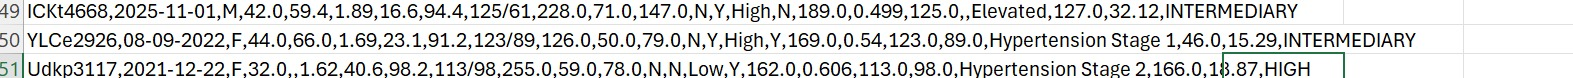

Para solucionar esto igualmente lo que se realiza es un borrado entero de la columna cualitativa (Low, Intermediary, High) pues ya refleja de por si el CVD Risk por ende es parte del objetivo.

 ## 4. Partición de los datos.

Una vez realizadas las tareas previas de limpieza, podemos separar los datos en dos conjuntos: entrenamiento (**train**), que se utilizará para entrenar el modelo de Regresión Lineal, y prueba (**test**).

In [61]:
target = "CVD Risk Score"
X = df_train_final.drop(columns=[target])
y = df_train_final[target]

En el código anterior realizamos la separación de las variables, donde `X` contiene todas las variables independientes que servirán como HDL, Diabetes Status, etc.

In [62]:
X

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Level,Systolic BP Extracted,Diastolic BP Extracted
0,isDx5313,"November 08, 2023",M,44.000000,114.300000,1.720,38.600000,100.000,112/83,228.0,...,N,172.000,0.581,112.0,83.000000,Hypertension Stage 1,121.0,HIGH,112.0,83.0
1,LHCK2961,20/03/2024,F,57.000000,92.923000,1.842,33.116000,106.315,101/91,158.0,...,Y,184.172,0.577,101.0,91.000000,Hypertension Stage 2,57.0,INTERMEDIARY,101.0,91.0
2,WjVn1699,2021-05-27,F,46.769697,73.400000,1.650,27.000000,78.100,90/74,135.0,...,N,165.000,0.473,90.0,74.000000,Normal,45.0,LOW,90.0,74.0
3,dCDO1109,"April 18, 2022",F,35.000000,113.300000,1.780,35.800000,79.600,92/89,158.0,...,Y,178.000,0.447,92.0,89.000000,Hypertension Stage 1,94.0,HIGH,92.0,89.0
4,pnpE1080,01/11/2024,F,48.000000,102.200000,1.750,33.400000,106.700,121/68,207.0,...,Y,175.000,0.610,121.0,68.000000,Elevated,128.0,HIGH,121.0,68.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1633,Dtdy6643,04/02/2020,F,52.000000,89.700000,1.880,25.400000,107.500,145/92,142.0,...,Y,188.000,0.572,145.0,92.000000,Hypertension Stage 2,42.0,HIGH,145.0,92.0
1634,mrzf5858,"May 21, 2021",F,35.000000,77.600000,1.780,24.500000,84.600,124/90,143.0,...,N,178.000,0.475,124.0,90.000000,Hypertension Stage 2,37.0,LOW,124.0,90.0
1635,nPnN5477,12/04/2022,F,35.000000,92.005000,1.726,28.472249,98.692,95/111,156.0,...,N,172.602,0.572,95.0,111.000000,Hypertension Stage 2,46.0,LOW,95.0,111.0
1637,QSFT6794,"September 06, 2025",M,49.000000,85.880566,1.630,23.100000,93.800,144/91,191.0,...,Y,163.000,0.575,144.0,82.878344,Hypertension Stage 2,82.0,HIGH,144.0,91.0


In [63]:
y

0       19.880
1       16.833
2       12.600
3       14.920
4       18.870
         ...  
1633    17.170
1634    13.960
1635    14.316
1637    17.640
1638    15.060
Name: CVD Risk Score, Length: 1551, dtype: float64


Una vez confirmada la correcta separación de las variables, estamos listos para dividir el conjunto de datos en entrenamiento (**train**) y prueba (**test**). Esta decisión depende del modelador; en este caso, se utilizará el 75 % de los datos para entrenar el modelo y el 25 % restante para evaluarlo. Esta proporción permite contar con suficiente información para el aprendizaje, al tiempo que se reserva un conjunto de datos no visto para medir el rendimiento en nuevos ejemplos. Para realizar esta división se emplea la función `train_test_split()`, que recibe las variables explicativas `X`, la variable objetivo `y`, la proporción del conjunto de prueba (`test_size=0.25`) y el parámetro `random_state` en 42, que garantiza que la partición sea reproducible y que los resultados puedan compararse entre ejecuciones.


In [64]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42)


Adicionalmente, podemos ver el tamaño de cada conjunto en donde el 75% serán los datos de entrenamiento el otro 25% serán los que estimará:


In [65]:
#Datos a entrenar el modelo
X_train.shape, y_train.shape

((1163, 25), (1163,))

In [66]:
#Datos a testear
X_test.shape, y_test.shape

((388, 25), (388,))

## 5. Normalización de variables categóricas y verificación de Validez



Se procede a normalizar las variables categóricas antes mencionadas y documentadas a continuación:

In [67]:
def normalizar_variables_categoricas(df_train, df_test):
    """
    Normaliza y codifica variables categóricas para el modelo de regresión.
    Transformaciones realizadas:
    - Sex: M/F -> 1/0 (binario)
    - Smoking Status: Yes/No -> 1/0 (binario)
    - Diabetes Status: Yes/No -> 1/0 (binario)
    - Family History of CVD: Yes/No -> 1/0 (binario)
    - Physical Activity Level: Low/Moderate/High -> 0/1/2 (ordinal)
    - Blood Pressure Category: Normal/Elevated/Stage1/Stage2 -> 0/1/2/3 (ordinal)
    - CVD Risk Level: Low/Intermediate/High -> 0/1/2 (ordinal) - solo en train
    Parametros:
    - df_train: DataFrame de entrenamiento
    - df_test: DataFrame de prueba
    Retorna:
    - df_train_norm: DataFrame de entrenamiento con variables normalizadas
    - df_test_norm: DataFrame de prueba con variables normalizadas
    - mapeos: Diccionario con los mapeos utilizados
    """
    print("=" * 80)
    print("NORMALIZACION DE VARIABLES CATEGORICAS")
    print("=" * 80)
    df_train_norm = df_train.copy()
    df_test_norm = df_test.copy()
    mapeos = {}
    print("\nIDENTIFICACION DE VARIABLES CATEGORICAS")
    print("-" * 80)
    excluir = ['Patient ID', 'Date of Service', 'CVD Risk Score']   
    categoricas_train = df_train_norm.select_dtypes(include=['object', 'bool']).columns.tolist()
    categoricas_train = [col for col in categoricas_train if col not in excluir]
    print(f"\nVariables categoricas encontradas en TRAIN: {len(categoricas_train)}")
    for col in categoricas_train:
        valores_unicos = df_train_norm[col].nunique()
        ejemplos = df_train_norm[col].value_counts().head(3).index.tolist()
        print(f"  - {col}: {valores_unicos} valores unicos | Ejemplos: {ejemplos}")
    print("\n" + "=" * 80)
    print("NORMALIZACION DE VARIABLES BINARIAS")
    print("=" * 80)
    variables_binarias = {
        'Sex': {'M': 1, 'F': 0, 'Male': 1, 'Female': 0, 'm': 1, 'f': 0},
        'Smoking Status': {'Yes': 1, 'No': 0, 'Y': 1, 'N': 0, 'yes': 1, 'no': 0, True: 1, False: 0},
        'Diabetes Status': {'Yes': 1, 'No': 0, 'Y': 1, 'N': 0, 'yes': 1, 'no': 0, True: 1, False: 0},
        'Family History of CVD': {'Yes': 1, 'No': 0, 'Y': 1, 'N': 0, 'yes': 1, 'no': 0, True: 1, False: 0}
    }
    for variable, mapeo in variables_binarias.items():
        if variable in df_train_norm.columns:
            print(f"\nNormalizando: {variable}")
            dist_original_train = df_train_norm[variable].value_counts()
            print(f"  Distribución original (TRAIN):")
            for valor, count in dist_original_train.items():
                print(f"    {valor}: {count} ({count/len(df_train_norm)*100:.2f}%)")
            df_train_norm[variable] = df_train_norm[variable].map(mapeo)
            valores_no_mapeados_train = df_train_norm[variable].isna().sum()
            if valores_no_mapeados_train > 0:
                print(f"  Advertencia: {valores_no_mapeados_train} valores no pudieron ser mapeados en TRAIN")
            dist_normalizada_train = df_train_norm[variable].value_counts()
            print(f"  Distribución normalizada (TRAIN):")
            for valor, count in dist_normalizada_train.items():
                print(f"    {valor}: {count} ({count/len(df_train_norm)*100:.2f}%)")
            if variable in df_test_norm.columns:
                dist_original_test = df_test_norm[variable].value_counts()
                print(f"  Distribución original (TEST):")
                for valor, count in dist_original_test.items():
                    print(f"    {valor}: {count} ({count/len(df_test_norm)*100:.2f}%)")
                df_test_norm[variable] = df_test_norm[variable].map(mapeo)
                valores_no_mapeados_test = df_test_norm[variable].isna().sum()
                if valores_no_mapeados_test > 0:
                    print(f"  Advertencia: {valores_no_mapeados_test} valores no pudieron ser mapeados en TEST")
            mapeos[variable] = mapeo
            print(f"  Mapeo aplicado: {mapeo}")
    print("\n" + "=" * 80)
    print("NORMALIZACION DE VARIABLES ORDINALES")
    print("=" * 80)
    if 'Physical Activity Level' in df_train_norm.columns:
        print("\nNormalizando: Physical Activity Level")
        mapeo_activity = {
            'Low': 0, 'low': 0, 'L': 0,
            'Moderate': 1, 'moderate': 1, 'M': 1, 'Medium': 1, 'medium': 1,
            'High': 2, 'high': 2, 'H': 2
        }
        dist_original_train = df_train_norm['Physical Activity Level'].value_counts()
        print(f"  Distribución original (TRAIN):")
        for valor, count in dist_original_train.items():
            print(f"    {valor}: {count} ({count/len(df_train_norm)*100:.2f}%)")
        df_train_norm['Physical Activity Level'] = df_train_norm['Physical Activity Level'].map(mapeo_activity)
        dist_normalizada_train = df_train_norm['Physical Activity Level'].value_counts().sort_index()
        print(f"  Distribución normalizada (TRAIN):")
        etiquetas_activity = {0: 'Low', 1: 'Moderate', 2: 'High'}
        for valor, count in dist_normalizada_train.items():
            etiqueta = etiquetas_activity.get(valor, 'Unknown')
            print(f"    {valor} ({etiqueta}): {count} ({count/len(df_train_norm)*100:.2f}%)")
        if 'Physical Activity Level' in df_test_norm.columns:
            dist_original_test = df_test_norm['Physical Activity Level'].value_counts()
            print(f"  Distribución original (TEST):")
            for valor, count in dist_original_test.items():
                print(f"    {valor}: {count} ({count/len(df_test_norm)*100:.2f}%)")
            df_test_norm['Physical Activity Level'] = df_test_norm['Physical Activity Level'].map(mapeo_activity)
        mapeos['Physical Activity Level'] = mapeo_activity
        print(f"  Mapeo aplicado: Low=0, Moderate=1, High=2")
    if 'Blood Pressure Category' in df_train_norm.columns:
        print("\nNormalizando: Blood Pressure Category")
        mapeo_bp = {
            'Normal': 0, 'normal': 0,
            'Elevated': 1, 'elevated': 1, 'Elevada': 1, 'elevada': 1,
            'Hypertension Stage 1': 2, 'Stage 1': 2, 'Hipertension Etapa 1': 2, 
            'Hipertensión Etapa 1': 2, 'stage 1': 2, 'Stage1': 2,
            'Hypertension Stage 2': 3, 'Stage 2': 3, 'Hipertension Etapa 2': 3,
            'Hipertensión Etapa 2': 3, 'stage 2': 3, 'Stage2': 3
        }
        dist_original_train = df_train_norm['Blood Pressure Category'].value_counts()
        print(f"  Distribución original (TRAIN):")
        for valor, count in dist_original_train.items():
            print(f"    {valor}: {count} ({count/len(df_train_norm)*100:.2f}%)")
        df_train_norm['Blood Pressure Category'] = df_train_norm['Blood Pressure Category'].map(mapeo_bp)
        dist_normalizada_train = df_train_norm['Blood Pressure Category'].value_counts().sort_index()
        print(f"  Distribución normalizada (TRAIN):")
        etiquetas_bp = {0: 'Normal', 1: 'Elevated', 2: 'Stage 1', 3: 'Stage 2'}
        for valor, count in dist_normalizada_train.items():
            etiqueta = etiquetas_bp.get(valor, 'Unknown')
            print(f"    {valor} ({etiqueta}): {count} ({count/len(df_train_norm)*100:.2f}%)")
        if 'Blood Pressure Category' in df_test_norm.columns:
            dist_original_test = df_test_norm['Blood Pressure Category'].value_counts()
            print(f"  Distribución original (TEST):")
            for valor, count in dist_original_test.items():
                print(f"    {valor}: {count} ({count/len(df_test_norm)*100:.2f}%)")
            df_test_norm['Blood Pressure Category'] = df_test_norm['Blood Pressure Category'].map(mapeo_bp)
        mapeos['Blood Pressure Category'] = mapeo_bp
        print(f"  Mapeo aplicado: Normal=0, Elevated=1, Stage1=2, Stage2=3")
    if 'CVD Risk Level' in df_train_norm.columns:
        print("\nNormalizando: CVD Risk Level (solo TRAIN)")
        mapeo_risk = {
            'Low': 0, 'low': 0, 'Bajo': 0, 'bajo': 0,
            'Intermediate': 1, 'intermediate': 1, 'Medium': 1, 'medium': 1,
            'Intermedio': 1, 'intermedio': 1, 'Moderado': 1, 'moderado': 1,
            'High': 2, 'high': 2, 'Alto': 2, 'alto': 2
        }
        dist_original_train = df_train_norm['CVD Risk Level'].value_counts()
        print(f"  Distribución original (TRAIN):")
        for valor, count in dist_original_train.items():
            print(f"    {valor}: {count} ({count/len(df_train_norm)*100:.2f}%)")
        df_train_norm['CVD Risk Level'] = df_train_norm['CVD Risk Level'].map(mapeo_risk)
        dist_normalizada_train = df_train_norm['CVD Risk Level'].value_counts().sort_index()
        print(f"  Distribución normalizada (TRAIN):")
        etiquetas_risk = {0: 'Low', 1: 'Intermediate', 2: 'High'}
        for valor, count in dist_normalizada_train.items():
            etiqueta = etiquetas_risk.get(valor, 'Unknown')
            print(f"    {valor} ({etiqueta}): {count} ({count/len(df_train_norm)*100:.2f}%)")
        mapeos['CVD Risk Level'] = mapeo_risk
        print(f"  Mapeo aplicado: Low=0, Intermediate=1, High=2")
    # Normalización BLOOD PRESSURE (formato "112/83 -> Systolic=112, Diastolic=83)
    print("\n" + "=" * 80)
    print("PROCESAMIENTO DE BLOOD PRESSURE")
    print("=" * 80)
    if 'Blood Pressure (mmHg)' in df_train_norm.columns:
        print("\nProcesando: Blood Pressure (mmHg)")
        if df_train_norm['Blood Pressure (mmHg)'].dtype == 'object':
            print("  Formato detectado: Sistólica/Diastólica (ej: 112/83)")
            ejemplos = df_train_norm['Blood Pressure (mmHg)'].dropna().head(5).tolist()
            print(f"  Ejemplos: {ejemplos}")
            print("  Acción: Se eliminará esta columna (redundante con Systolic BP y Diastolic BP)")
            df_train_norm = df_train_norm.drop('Blood Pressure (mmHg)', axis=1)
        else:
            print("  La columna ya es numérica, se mantiene")
    if 'Blood Pressure (mmHg)' in df_test_norm.columns:
        if df_test_norm['Blood Pressure (mmHg)'].dtype == 'object':
            print("\n  Eliminando Blood Pressure (mmHg) en TEST")
            df_test_norm = df_test_norm.drop('Blood Pressure (mmHg)', axis=1)
    print("\n" + "=" * 80)
    print("VERIFICACION DE VARIABLES NO NORMALIZADAS")
    print("=" * 80)
    categoricas_restantes_train = df_train_norm.select_dtypes(include=['object']).columns.tolist()
    categoricas_restantes_train = [col for col in categoricas_restantes_train if col not in excluir]
    if categoricas_restantes_train:
        print(f"\nAdvertencia: Quedan {len(categoricas_restantes_train)} variables categóricas sin normalizar en TRAIN:")
        for col in categoricas_restantes_train:
            valores_unicos = df_train_norm[col].nunique()
            ejemplos = df_train_norm[col].value_counts().head(3).index.tolist()
            print(f"  - {col}: {valores_unicos} valores unicos | Ejemplos: {ejemplos}")
        print("\nEstas variables pueden requerir codificación adicional (One-Hot Encoding)")
    else:
        print("\nTodas las variables categóricas han sido normalizadas correctamente en TRAIN")
    categoricas_restantes_test = df_test_norm.select_dtypes(include=['object']).columns.tolist()
    categoricas_restantes_test = [col for col in categoricas_restantes_test if col not in excluir]
    if categoricas_restantes_test:
        print(f"\nAdvertencia: Quedan {len(categoricas_restantes_test)} variables categóricas sin normalizar en TEST:")
        for col in categoricas_restantes_test:
            valores_unicos = df_test_norm[col].nunique()
            ejemplos = df_test_norm[col].value_counts().head(3).index.tolist()
            print(f"  - {col}: {valores_unicos} valores unicos | Ejemplos: {ejemplos}")
    else:
        print("\nTodas las variables categóricas han sido normalizadas correctamente en TEST")
    print("\n" + "=" * 80)
    print("VERIFICACION DE VALORES NULOS POST-NORMALIZACION")
    print("=" * 80)
    nulos_nuevos_train = {}
    for col in mapeos.keys():
        if col in df_train_norm.columns:
            nulos = df_train_norm[col].isna().sum()
            if nulos > 0:
                nulos_nuevos_train[col] = nulos
    if nulos_nuevos_train:
        print("\nAdvertencia: Se generaron valores nulos en TRAIN durante la normalización:")
        for col, nulos in nulos_nuevos_train.items():
            print(f"  - {col}: {nulos} valores nulos ({nulos/len(df_train_norm)*100:.2f}%)")
        print("\nEstos valores deben ser revisados e imputados")
    else:
        print("\nNo se generaron valores nulos durante la normalización en TRAIN")
    nulos_nuevos_test = {}
    for col in mapeos.keys():
        if col in df_test_norm.columns:
            nulos = df_test_norm[col].isna().sum()
            if nulos > 0:
                nulos_nuevos_test[col] = nulos
    if nulos_nuevos_test:
        print("\nAdvertencia: Se generaron valores nulos en TEST durante la normalización:")
        for col, nulos in nulos_nuevos_test.items():
            print(f"  - {col}: {nulos} valores nulos ({nulos/len(df_test_norm)*100:.2f}%)")
        print("\nEstos valores deben ser revisados e imputados")
    else:
        print("\nNo se generaron valores nulos durante la normalización en TEST")
    print("\n" + "=" * 80)
    print("RESUMEN FINAL DE NORMALIZACION")
    print("=" * 80)
    print(f"\nVariables normalizadas: {len(mapeos)}")
    for variable in mapeos.keys():
        print(f"  - {variable}")
    print(f"\nTipos de datos finales (TRAIN):")
    tipos_train = df_train_norm.dtypes.value_counts()
    for tipo, count in tipos_train.items():
        print(f"  - {tipo}: {count} columnas")
    print(f"\nTipos de datos finales (TEST):")
    tipos_test = df_test_norm.dtypes.value_counts()
    for tipo, count in tipos_test.items():
        print(f"  - {tipo}: {count} columnas")
    print("\n" + "=" * 80)
    print("NORMALIZACION DE VARIABLES CATEGORICAS COMPLETADA")
    print("=" * 80)
    return df_train_norm, df_test_norm, mapeos
# print("\nMapeos utilizados:")
#     print(f"{variable}: {mapeo}")

Se hace uso de las funciones de unicidad e imputación nuevamente con el fin de que los valores no sufrieran transformacioenes durante la normalización de las variables categóricas.

In [68]:
df_train_imputado, df_test_imputado, reporte_imputacion = imputar_valores_nulos_con_media(
    df_train_limpio, 
    df_test
)
df_train_final, df_test_final, reporte_unicidad = verificar_y_corregir_unicidad(
    df_train_imputado, 
    df_test_imputado
)
print("\nDatasets preparados y listos:")
print(f"  df_train_final: {df_train_final.shape}")
print(f"  df_test_final: {df_test_final.shape}")

 IMPUTACIÓN DE VALORES NULOS CON LA MEDIA

 DATASET DE ENTRENAMIENTO - Análisis previo
--------------------------------------------------------------------------------

Columnas numéricas a evaluar: 15

  Se encontraron 13 columnas con valores nulos:

                     Columna  Valores Nulos % Nulos    Media
                         Age             67   4.16%  46.7697
                 Weight (kg)             72   4.47%  85.8806
                  Height (m)             60   3.73%   1.7577
                         BMI             51   3.17%  28.4722
Abdominal Circumference (cm)             59   3.66%  91.5577
   Total Cholesterol (mg/dL)             68   4.22% 198.9712
                 HDL (mg/dL)             82   5.09%  56.1641
 Fasting Blood Sugar (mg/dL)             53   3.29% 117.8943
                 Height (cm)             68   4.22% 175.7372
       Waist-to-Height Ratio             76   4.72%   0.5225
                 Systolic BP             60   3.73% 125.7447
                

C:\Users\Santiago\AppData\Local\Temp\ipykernel_16176\3530703143.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train_imputado[col].fillna(media, inplace=True)
C:\Users\Santiago\AppData\Local\Temp\ipykernel_16176\3530703143.py:105: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop


  Resultado del parseo:
    Fechas validas: 1610
    Fechas invalidas: 0

  Ejemplos de fechas parseadas:
    1. 2023-11-08 00:00:00
    2. 2024-03-20 00:00:00
    3. 2021-05-27 00:00:00
    4. 2022-04-18 00:00:00
    5. 2024-11-01 00:00:00

Dataset: TEST
  Ejemplos de fechas originales:
    1. 1/12/2021
    2. 12-25-2020
    3. 23-sep-21
    4. 3/03/2021
    5. 06-14-2022

  Resultado del parseo:
    Fechas validas: 194
    Fechas invalidas: 0

  Ejemplos de fechas parseadas:
    1. 2021-12-01 00:00:00
    2. 2020-12-25 00:00:00
    3. 2021-09-23 00:00:00
    4. 2021-03-03 00:00:00
    5. 2022-06-14 00:00:00

PASO 2: ANALISIS DE DUPLICADOS POR PATIENT ID

--- Dataset: TRAIN ---

Estadisticas basicas:
  Total de registros: 1610
  IDs unicos: 1349
  Registros con ID duplicado: 261
  Numero de IDs que se repiten: 170

  Ejemplos de IDs duplicados:
    oSqq7069: aparece 3 veces
    gBFe4249: aparece 3 veces
    AhYt1346: aparece 3 veces
    RlsB8509: aparece 3 veces
    Pymh0850: aparece

Una vez se verifica y se normalizan los datos y variables categóricas a númericas se procede a dropear las columnas que no incluiremos al análisis.

Para luego definir las transformaciones necesarias para el modelo de regresión lineal. En el caso de las variables categóricas, se aplicarán las siguientes operaciones de codificación.

- Tratamiento de valores faltantes (completitud): el modelo de regresión lineal no puede trabajar con valores nulos, por lo que estos se borraron en la columna CVD Risk Score y se imputaron los datos vacios por la mediana con el fin de que

- **Codificación binaria:** Las variables categóricas dicotómicas (Sex, Smoking Status, Diabetes Status, Family History of CVD) se transformaron a valores 0/1, representando la ausencia o presencia de la característica.

- **Codificación ordinal:** Las variables categóricas con orden inherente (Physical Activity Level, Blood Pressure Category, CVD Risk Level) se transformaron mediante **Ordinal Encoding**, asignando valores numéricos crecientes según el nivel de la categoría.

- **Eliminación de variables redundantes:** La variable "Blood Pressure (mmHg)" fue eliminada debido a que la información ya se encuentra representada en las variables numéricas Systolic BP y Diastolic BP.


In [69]:
cols_to_drop = ["Patient ID", "Date of Service", "CVD Risk Level", "Blood Pressure (mmHg)"]
def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors="ignore")
variable_objetivo = 'CVD Risk Score'
if variable_objetivo in X_train.columns:
    X_train = X_train.drop(variable_objetivo, axis=1)
if variable_objetivo in X_test.columns:
    X_test = X_test.drop(variable_objetivo, axis=1)
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de y_train:", y_train.shape)
print("\nColumnas en X_train:")
print(X_train.columns.tolist())
columnas_object = X_train.select_dtypes(include=['object']).columns.tolist()
if columnas_object:
    print(f"\nAdvertencia: Columnas no numéricas encontradas: {columnas_object}")
    print("Eliminando columnas no numéricas...")
    X_train = X_train.select_dtypes(include=[np.number])
    X_test = X_test.select_dtypes(include=[np.number])
print("\nColumnas finales en X_train:", X_train.columns.tolist())
print("Dimensiones finales de X_train:", X_train.shape)
print("\nValores nulos en X_train:", X_train.isnull().sum().sum())
print("Valores nulos en y_train:", y_train.isnull().sum())
Modelo = LinearRegression()
Modelo.fit(X_train, y_train)
print("\nModelo entrenado exitosamente")
y_pred_train = Modelo.predict(X_train)
y_pred_test = Modelo.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
r2 = r2_score(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae = mean_absolute_error(y_train, y_pred_train)
print("\nMétricas del modelo:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
importancia = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': Modelo.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)
print("\nTop 10 variables más importantes:")
print(importancia.head(10))


Dimensiones de X_train: (1163, 25)
Dimensiones de y_train: (1163,)

Columnas en X_train:
['Patient ID', 'Date of Service', 'Sex', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Blood Pressure (mmHg)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Height (cm)', 'Waist-to-Height Ratio', 'Systolic BP', 'Diastolic BP', 'Blood Pressure Category', 'Estimated LDL (mg/dL)', 'CVD Risk Level', 'Systolic BP Extracted', 'Diastolic BP Extracted']

Advertencia: Columnas no numéricas encontradas: ['Patient ID', 'Date of Service', 'Sex', 'Blood Pressure (mmHg)', 'Smoking Status', 'Diabetes Status', 'Physical Activity Level', 'Family History of CVD', 'Blood Pressure Category', 'CVD Risk Level']
Eliminando columnas no numéricas...

Columnas finales en X_train: ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/


Una vez realizadas las normalizaciones y las tranformaciones de las variables categóricas a númericas se procede a realizar la regresión lineal y el análisis del R^2.

Notando inicialmente qeu el valor del R^2 es realmente bajo. Lo cual es realmente congruente con las correlaciones obtenidas aunque nos motiva a buscar modelos alternativos.

Métricas del modelo:
  R² Score: 0.0252
  RMSE: 10.6784
  MAE: 3.7108

-------- Top 10 variables más importantes --------

| # | Feature                          | Coeficiente |
|---|----------------------------------|-----------:|
| 1 | Waist-to-Height Ratio            | 11.365268  |
| 2 | Height (m)                       | 5.789495   |
| 3 | BMI                              | 0.191456   |
| 4 | Abdominal Circumference (cm)     | -0.076038  |
| 5 | Age                              | -0.041396  |
| 6 | Systolic BP                      | 0.037561   |
| 7 | Weight (kg)                      | -0.032326  |
| 8 | HDL (mg/dL)                      | -0.019922  |
| 9 | Diastolic BP                     | 0.018474   |
|10 | Height (cm)                      | -0.018176  |



Debido a estos valores entonces se decide hacer un ajuste al modelo y usar rotros que sean aún lineales como

In [70]:
def diagnosticar_modelo(df_train, X_train, y_train):
    """
    Diagnostica problemas potenciales que afectan el rendimiento del modelo.
    """
    print("=" * 80)
    print("DIAGNOSTICO DEL MODELO")
    print("=" * 80)
    print("\nPASO 1: ANALISIS DE CORRELACIONES")
    print("-" * 80)
    df_analisis = X_train.copy()
    df_analisis['CVD Risk Score'] = y_train
    corr_matrix = df_analisis.corr()
    corr_con_objetivo = corr_matrix['CVD Risk Score'].drop('CVD Risk Score').sort_values(ascending=False)
    print("\nCorrelación de cada feature con CVD Risk Score:")
    print("-" * 60)
    for feature, corr in corr_con_objetivo.items():
        print(f"  {feature:40s}: {corr:7.4f}")
    features_baja_corr = corr_con_objetivo[abs(corr_con_objetivo) < 0.1]
    if len(features_baja_corr) > 0:
        print(f"\nAdvertencia: {len(features_baja_corr)} features tienen correlación muy baja (<0.1):")
        for feature in features_baja_corr.index:
            print(f"  - {feature}")
    print("\n" + "=" * 80)
    print("PASO 2: DETECCION DE MULTICOLINEALIDAD")
    print("-" * 80)
    print("\nPares de features con correlación alta (>0.9):")
    pares_correlacionados = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            if col1 == 'CVD Risk Score' or col2 == 'CVD Risk Score':
                continue
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.9:
                pares_correlacionados.append((col1, col2, corr_val))
                print(f"  {col1:30s} <-> {col2:30s}: {corr_val:.4f}")
    if len(pares_correlacionados) == 0:
        print("  No se encontraron pares con correlación >0.9")
    print("\n" + "=" * 80)
    print("PASO 3: ANALISIS DE LA VARIABLE OBJETIVO")
    print("-" * 80)
    print(f"\nEstadísticas de CVD Risk Score:")
    print(f"  Media: {y_train.mean():.4f}")
    print(f"  Desviación estándar: {y_train.std():.4f}")
    print(f"  Mínimo: {y_train.min():.4f}")
    print(f"  Máximo: {y_train.max():.4f}")
    print(f"  Rango: {y_train.max() - y_train.min():.4f}")
    coef_variacion = y_train.std() / y_train.mean()
    print(f"  Coeficiente de variación: {coef_variacion:.4f}")
    if coef_variacion < 0.1:
        print("\n  Advertencia: Baja variabilidad en la variable objetivo")
    print("\n" + "=" * 80)
    print("PASO 4: VERIFICACION DE FORMULA OCULTA")
    print("-" * 80)
    print("\nVerificando si CVD Risk Score es una combinación de otras variables...")
    if 'CVD Risk Level' in df_train.columns:
        risk_levels = df_train['CVD Risk Level'].value_counts()
        print(f"\nDistribución de CVD Risk Level en datos originales:")
        for level, count in risk_levels.items():
            print(f"  {level}: {count}")
    print("\n" + "=" * 80)
    print("PASO 5: ANALISIS DE VARIANZA DE FEATURES")
    print("-" * 80)
    print("\nVarianza de cada feature:")
    varianzas = X_train.var().sort_values(ascending=False)
    for feature, var in varianzas.items():
        print(f"  {feature:40s}: {var:12.4f}")
    features_baja_var = varianzas[varianzas < 0.01]
    if len(features_baja_var) > 0:
        print(f"\nAdvertencia: {len(features_baja_var)} features con varianza muy baja (<0.01):")
        for feature in features_baja_var.index:
            print(f"  - {feature}")
    print("\n" + "=" * 80)
    print("RECOMENDACIONES")
    print("=" * 80)
    recomendaciones = []
    if len(features_baja_corr) > 5:
        recomendaciones.append(
            f"Eliminar features con baja correlación: {len(features_baja_corr)} features no aportan"
        )
    if len(pares_correlacionados) > 0:
        recomendaciones.append(
            f"Resolver multicolinealidad: {len(pares_correlacionados)} pares correlacionados detectados"
        )
        recomendaciones.append(
            "  - Eliminar Height (cm) y mantener Height (m)"
        )
        recomendaciones.append(
            "  - Considerar eliminar BMI o Waist-to-Height Ratio (calculadas)"
        )
    if coef_variacion < 0.1:
        recomendaciones.append(
            "La variable objetivo tiene muy poca variabilidad"
        )
    recomendaciones.append(
        "El modelo lineal simple puede no ser adecuado para este problema"
    )
    recomendaciones.append(
        "Considerar: Regularización (Ridge/Lasso), selección de features, o modelos no lineales"
    )
    print("\n")
    for i, rec in enumerate(recomendaciones, 1):
        print(f"{i}. {rec}")
    return corr_con_objetivo, pares_correlacionados
def crear_modelo_mejorado(X_train, y_train):
    """
    Crea un modelo con features seleccionadas eliminando multicolinealidad.
    """
    print("\n" + "=" * 80)
    print("CREANDO MODELO MEJORADO")
    print("=" * 80)
    features_eliminar = [
        'Height (cm)',  # Redundante con Height (m)
        'BMI',  # Calculada a partir de Weight y Height
    ]
    X_train_mejorado = X_train.drop(columns=features_eliminar, errors='ignore')
    print(f"\nFeatures eliminadas: {features_eliminar}")
    print(f"Features restantes: {X_train_mejorado.shape[1]}")
    print(f"\nColumnas finales:")
    for col in X_train_mejorado.columns:
        print(f"  - {col}")
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    modelo_mejorado = LinearRegression()
    modelo_mejorado.fit(X_train_mejorado, y_train)
    y_pred = modelo_mejorado.predict(X_train_mejorado)
    r2 = r2_score(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    mae = mean_absolute_error(y_train, y_pred)
    print("\nMétricas del modelo mejorado:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print("\n¿Mejora respecto al modelo original (R²=0.0536)?")
    if r2 > 0.0536:
        mejora = ((r2 - 0.0536) / 0.0536) * 100
        print(f"  Sí, mejora de {mejora:.2f}%")
    else:
        print(f"  No, empeora")
    return modelo_mejorado, X_train_mejorado


Top 5 correlaciones más altas con CVD Risk Score:
Gráfico guardado


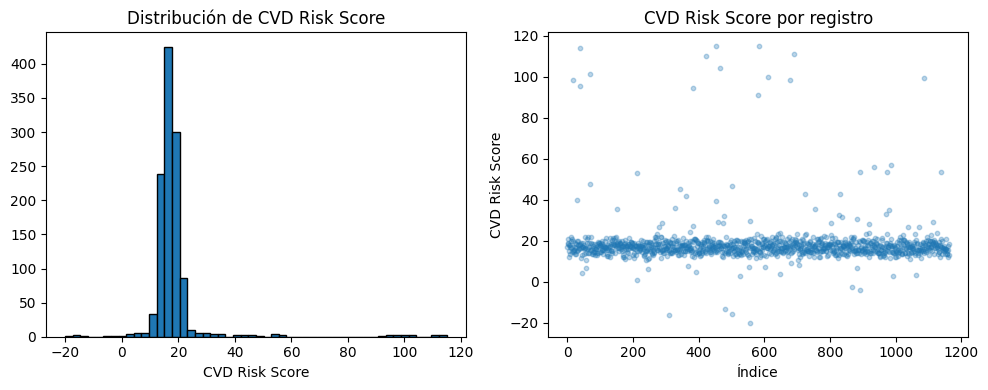

In [71]:
print("\nTop 5 correlaciones más altas con CVD Risk Score:")
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y_train, bins=50, edgecolor='black')
plt.title('Distribución de CVD Risk Score')
plt.xlabel('CVD Risk Score')
plt.subplot(1, 2, 2)
plt.scatter(range(len(y_train)), y_train, alpha=0.3, s=10)
plt.title('CVD Risk Score por registro')
plt.xlabel('Índice')
plt.ylabel('CVD Risk Score')
plt.tight_layout()
print("Gráfico guardado")

In [72]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
def probar_modelos_alternativos(X_train, y_train, X_test):
    """
    Prueba diferentes modelos y técnicas para mejorar el rendimiento.
    """
    print("=" * 80)
    print("PROBANDO MODELOS ALTERNATIVOS")
    print("=" * 80)
    resultados = {}
    print("\n1. Ridge Regression (regularización L2)")
    print("-" * 60)
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train, y_train)
    y_pred_ridge = ridge.predict(X_train)
    r2_ridge = r2_score(y_train, y_pred_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_train, y_pred_ridge))
    mae_ridge = mean_absolute_error(y_train, y_pred_ridge)
    print(f"  R² Score: {r2_ridge:.4f}")
    print(f"  RMSE: {rmse_ridge:.4f}")
    print(f"  MAE: {mae_ridge:.4f}")
    resultados['Ridge'] = {
        'modelo': ridge,
        'r2': r2_ridge,
        'rmse': rmse_ridge,
        'mae': mae_ridge
    }
    print("\n2. Lasso Regression (regularización L1)")
    print("-" * 60)
    lasso = Lasso(alpha=0.1)
    lasso.fit(X_train, y_train)
    y_pred_lasso = lasso.predict(X_train)
    r2_lasso = r2_score(y_train, y_pred_lasso)
    rmse_lasso = np.sqrt(mean_squared_error(y_train, y_pred_lasso))
    mae_lasso = mean_absolute_error(y_train, y_pred_lasso)
    print(f"  R² Score: {r2_lasso:.4f}")
    print(f"  RMSE: {rmse_lasso:.4f}")
    print(f"  MAE: {mae_lasso:.4f}")
    features_seleccionadas = X_train.columns[lasso.coef_ != 0]
    print(f"\n  Features seleccionadas por Lasso: {len(features_seleccionadas)}/{len(X_train.columns)}")
    if len(features_seleccionadas) > 0:
        print(f"  Features: {list(features_seleccionadas)}")
    resultados['Lasso'] = {
        'modelo': lasso,
        'r2': r2_lasso,
        'rmse': rmse_lasso,
        'mae': mae_lasso
    }
    print("\n3. Random Forest Regressor")
    print("-" * 60)
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_train)
    r2_rf = r2_score(y_train, y_pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_train, y_pred_rf))
    mae_rf = mean_absolute_error(y_train, y_pred_rf)
    print(f"  R² Score: {r2_rf:.4f}")
    print(f"  RMSE: {rmse_rf:.4f}")
    print(f"  MAE: {mae_rf:.4f}")
    importancias = pd.DataFrame({
        'Feature': X_train.columns,
        'Importancia': rf.feature_importances_
    }).sort_values('Importancia', ascending=False)
    print(f"\n  Top 5 features más importantes:")
    for idx, row in importancias.head(5).iterrows():
        print(f"    {row['Feature']:40s}: {row['Importancia']:.4f}")
    resultados['Random Forest'] = {
        'modelo': rf,
        'r2': r2_rf,
        'rmse': rmse_rf,
        'mae': mae_rf,
        'importancias': importancias
    }
    print("\n4. Gradient Boosting Regressor")
    print("-" * 60)
    gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, 
                                    max_depth=5, random_state=42)
    gb.fit(X_train, y_train)
    y_pred_gb = gb.predict(X_train)
    r2_gb = r2_score(y_train, y_pred_gb)
    rmse_gb = np.sqrt(mean_squared_error(y_train, y_pred_gb))
    mae_gb = mean_absolute_error(y_train, y_pred_gb)
    print(f"  R² Score: {r2_gb:.4f}")
    print(f"  RMSE: {rmse_gb:.4f}")
    print(f"  MAE: {mae_gb:.4f}")
    resultados['Gradient Boosting'] = {
        'modelo': gb,
        'r2': r2_gb,
        'rmse': rmse_gb,
        'mae': mae_gb
    }
    print("\n5. Polynomial Regression (grado 2)")
    print("-" * 60)
    print("  Advertencia: Puede tardar con muchas features...")
    if X_train.shape[1] <= 10:
        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_train_poly = poly.fit_transform(X_train)
        from sklearn.linear_model import LinearRegression
        lr_poly = LinearRegression()
        lr_poly.fit(X_train_poly, y_train)
        y_pred_poly = lr_poly.predict(X_train_poly)
        r2_poly = r2_score(y_train, y_pred_poly)
        rmse_poly = np.sqrt(mean_squared_error(y_train, y_pred_poly))
        mae_poly = mean_absolute_error(y_train, y_pred_poly)
        print(f"  Features expandidas: {X_train.shape[1]} -> {X_train_poly.shape[1]}")
        print(f"  R² Score: {r2_poly:.4f}")
        print(f"  RMSE: {rmse_poly:.4f}")
        print(f"  MAE: {mae_poly:.4f}")
        resultados['Polynomial'] = {
            'modelo': lr_poly,
            'poly': poly,
            'r2': r2_poly,
            'rmse': rmse_poly,
            'mae': mae_poly
        }
    else:
        print(f"  Omitido: demasiadas features ({X_train.shape[1]})")
        print(f"  Resultaría en {X_train.shape[1] * (X_train.shape[1] + 1) // 2} features")
    print("\n" + "=" * 80)
    print("COMPARACION DE MODELOS")
    print("=" * 80)
    comparacion = pd.DataFrame({
        'Modelo': list(resultados.keys()),
        'R² Score': [resultados[m]['r2'] for m in resultados.keys()],
        'RMSE': [resultados[m]['rmse'] for m in resultados.keys()],
        'MAE': [resultados[m]['mae'] for m in resultados.keys()]
    }).sort_values('R² Score', ascending=False)
    print("\n" + comparacion.to_string(index=False))
    mejor_modelo_nombre = comparacion.iloc[0]['Modelo']
    mejor_r2 = comparacion.iloc[0]['R² Score']
    print(f"\nMejor modelo: {mejor_modelo_nombre} (R² = {mejor_r2:.4f})")
    if mejor_r2 < 0.3:
        print("\nAdvertencia: Incluso el mejor modelo tiene R² < 0.3")
        print("Esto sugiere que:")
        print("  1. Las variables disponibles no predicen bien CVD Risk Score")
        print("  2. Puede haber relaciones muy complejas o no lineales")
        print("  3. Los datos pueden tener problemas de calidad")
        print("  4. Falta información crítica en el dataset")
    return resultados, comparacion
def seleccionar_features_importantes(X_train, y_train, umbral=0.01):
    """
    Selecciona solo las features más importantes usando Random Forest.
    """
    print("\n" + "=" * 80)
    print("SELECCION DE FEATURES IMPORTANTES")
    print("=" * 80)
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    importancias = pd.DataFrame({
        'Feature': X_train.columns,
        'Importancia': rf.feature_importances_
    }).sort_values('Importancia', ascending=False)
    print("\nImportancia de todas las features:")
    print(importancias.to_string(index=False))
    features_importantes = importancias[importancias['Importancia'] >= umbral]['Feature'].tolist()
    print(f"\nFeatures seleccionadas (importancia >= {umbral}): {len(features_importantes)}")
    for feature in features_importantes:
        imp = importancias[importancias['Feature'] == feature]['Importancia'].values[0]
        print(f"  - {feature:40s}: {imp:.4f}")
    X_train_reducido = X_train[features_importantes]
    print(f"\nDimensiones: {X_train.shape[1]} features -> {X_train_reducido.shape[1]} features")
    return X_train_reducido, features_importantes
# print("\nRe-entrenando con features seleccionadas...")


En este paso usamos `ColumnTransformer` para aplicar diferentes transformaciones según el tipo de variable. La idea es decirle explícitamente al modelo qué hacer con las columnas numéricas y qué hacer con las categóricas, dentro de un solo bloque de preprocesamiento.


SEPARACION DE BLOOD PRESSURE

Procesando 1639 registros...

Ejemplos de valores originales:
  1. 112/83
  2. 101/91
  3. 90/74
  4. 92/89
  5. 121/68

Resultados de la extracción:
  Valores extraídos exitosamente: 1639
  Valores nulos originales: 0
  Valores que no pudieron extraerse: 0

Estadísticas de Systolic BP Extracted:
  Media: 125.56
  Min: 90.00
  Max: 179.00

Estadísticas de Diastolic BP Extracted:
  Media: 83.09
  Min: 60.00
  Max: 119.00

Comparación con columnas existentes:
  Systolic BP coincide: 1568/1639
  Diastolic BP coincide: 1536/1639

  Las columnas extraídas coinciden con las existentes (>90%)
  Recomendación: Usar las columnas existentes Systolic BP y Diastolic BP

SEPARACION COMPLETADA
SEPARACION DE BLOOD PRESSURE

Procesando 194 registros...

Ejemplos de valores originales:
  1. 105/108
  2. 139/79
  3. 93/67
  4. 99/90
  5. 97/84

Resultados de la extracción:
  Valores extraídos exitosamente: 194
  Valores nulos originales: 0
  Valores que no pudieron extraers

C:\Users\Santiago\AppData\Local\Temp\ipykernel_16176\3530703143.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train_imputado[col].fillna(media, inplace=True)
C:\Users\Santiago\AppData\Local\Temp\ipykernel_16176\3530703143.py:105: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop


  Resultado del parseo:
    Fechas validas: 1610
    Fechas invalidas: 0

  Ejemplos de fechas parseadas:
    1. 2023-11-08 00:00:00
    2. 2024-03-20 00:00:00
    3. 2021-05-27 00:00:00
    4. 2022-04-18 00:00:00
    5. 2024-11-01 00:00:00

Dataset: TEST
  Ejemplos de fechas originales:
    1. 1/12/2021
    2. 12-25-2020
    3. 23-sep-21
    4. 3/03/2021
    5. 06-14-2022

  Resultado del parseo:
    Fechas validas: 194
    Fechas invalidas: 0

  Ejemplos de fechas parseadas:
    1. 2021-12-01 00:00:00
    2. 2020-12-25 00:00:00
    3. 2021-09-23 00:00:00
    4. 2021-03-03 00:00:00
    5. 2022-06-14 00:00:00

PASO 2: ANALISIS DE DUPLICADOS POR PATIENT ID

--- Dataset: TRAIN ---

Estadisticas basicas:
  Total de registros: 1610
  IDs unicos: 1349
  Registros con ID duplicado: 261
  Numero de IDs que se repiten: 170

  Ejemplos de IDs duplicados:
    oSqq7069: aparece 3 veces
    gBFe4249: aparece 3 veces
    AhYt1346: aparece 3 veces
    RlsB8509: aparece 3 veces
    Pymh0850: aparece

(LinearRegression(),
       Sex        Age  Weight (kg)  Height (m)  Abdominal Circumference (cm)  \
 0       1  44.000000   114.300000       1.720                       100.000   
 1       0  57.000000    92.923000       1.842                       106.315   
 2       0  46.769697    73.400000       1.650                        78.100   
 3       0  35.000000   113.300000       1.780                        79.600   
 4       0  48.000000   102.200000       1.750                       106.700   
 ...   ...        ...          ...         ...                           ...   
 1633    0  52.000000    89.700000       1.880                       107.500   
 1634    0  35.000000    77.600000       1.780                        84.600   
 1635    0  35.000000    92.005000       1.726                        98.692   
 1637    1  49.000000    85.880566       1.630                        93.800   
 1638    0  46.769697    59.200000       1.800                        71.900   
 
       Total Chol

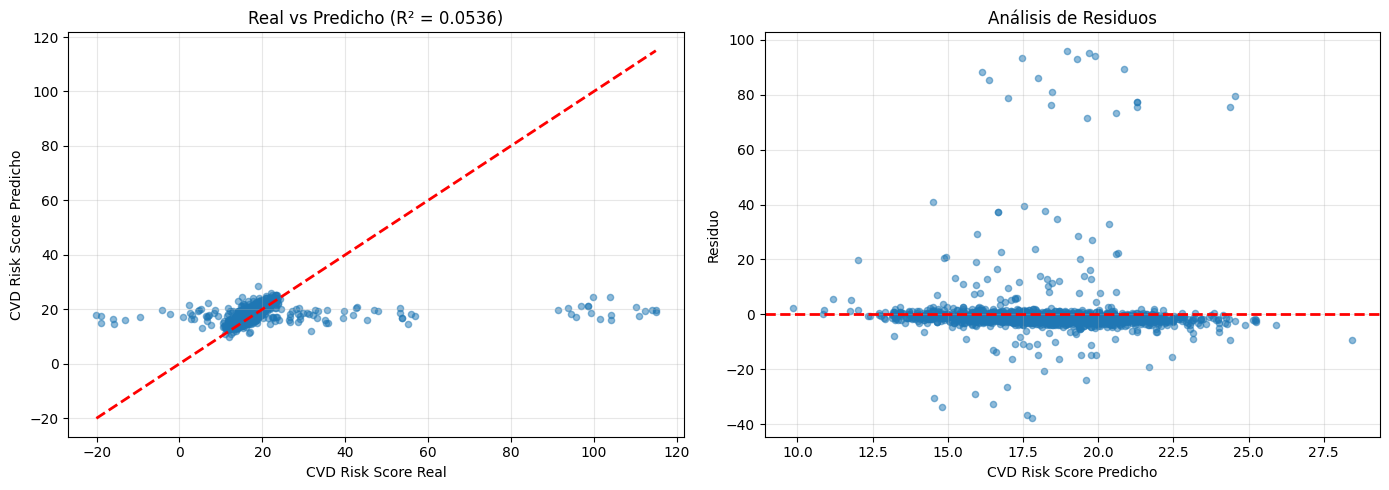

In [73]:
df_train = separar_blood_pressure(df_train)
df_test = separar_blood_pressure(df_test)
print("\nPASO 3: Combinando presiones sanguíneas...")
df_train = combinar_presiones_sanguineas(df_train)
df_test = combinar_presiones_sanguineas(df_test)
print("\nPASO 4: Verificando completitud...")
df_train_limpio = verificar_completitud(df_train, df_test)
print("\nPASO 5: Imputando valores nulos...")
df_train_imputado, df_test_imputado, reporte_imputacion = imputar_valores_nulos_con_media(
    df_train_limpio, 
    df_test
)
print("\nPASO 6: Verificando unicidad...")
df_train_unico, df_test_unico, reporte_unicidad = verificar_y_corregir_unicidad(
    df_train_imputado, 
    df_test_imputado
)
print("\nPASO 7: Normalizando variables categóricas...")
df_train_normalizado, df_test_normalizado, mapeos = normalizar_variables_categoricas(
    df_train_unico,
    df_test_unico
)
print("\nPASO 8: Preparando datos para modelado...")
cols_to_drop = ["Patient ID", "Date of Service", "CVD Risk Level"]
X_train = df_train_normalizado.drop(columns=cols_to_drop, errors="ignore")
X_test = df_test_normalizado.drop(columns=cols_to_drop, errors="ignore")
variable_objetivo = 'CVD Risk Score'
y_train = df_train_normalizado[variable_objetivo].copy()
if variable_objetivo in X_train.columns:
    X_train = X_train.drop(variable_objetivo, axis=1)
if variable_objetivo in X_test.columns:
    X_test = X_test.drop(variable_objetivo, axis=1)
X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])
print(f"X_train: {X_train.shape} | y_train: {y_train.shape} | X_test: {X_test.shape}")
print(f"\nFeatures ({X_train.shape[1]}):")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:2d}. {col}")
print("\n" + "=" * 80)
print("ANALISIS DE CORRELACIONES")
print("=" * 80)
df_corr = X_train.copy()
df_corr['CVD Risk Score'] = y_train
correlaciones = df_corr.corr()['CVD Risk Score'].drop('CVD Risk Score').sort_values(ascending=False)
print("\nTop 10 correlaciones más altas:")
for feature, corr in correlaciones.head(10).items():
    print(f"  {feature:40s}: {corr:7.4f}")
print("\n" + "=" * 80)
print("MODELO DE REGRESION LINEAL")
print("=" * 80)
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)
r2 = r2_score(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae = mean_absolute_error(y_train, y_pred_train)
print(f"\nMétricas en TRAIN:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
importancia = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': modelo.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)
print("\nTop 10 variables más importantes:")
print(importancia.head(10).to_string(index=False))
if r2 < 0.3:
    print("\n" + "=" * 80)
    print("R² BAJO - PROBANDO MODELOS ALTERNATIVOS")
    print("=" * 80)
    resultados, comparacion = probar_modelos_alternativos(X_train, y_train, X_test)
    mejor_modelo_nombre = comparacion.iloc[0]['Modelo']
    mejor_modelo = resultados[mejor_modelo_nombre]['modelo']
    mejor_r2 = comparacion.iloc[0]['R² Score']
    print(f"\nMEJOR MODELO: {mejor_modelo_nombre} (R² = {mejor_r2:.4f})")
    if mejor_modelo_nombre == 'Polynomial':
        poly = resultados['Polynomial']['poly']
        X_test_poly = poly.transform(X_test)
        y_pred_test_mejor = mejor_modelo.predict(X_test_poly)
    else:
        y_pred_test_mejor = mejor_modelo.predict(X_test)
    print("\nUsaremos el mejor modelo para las predicciones finales")
else:
    print("\nR² aceptable, usando regresión lineal")
    mejor_modelo = modelo
    y_pred_test_mejor = y_pred_test
print("\n" + "=" * 80)
print("GUARDANDO RESULTADOS")
print("=" * 80)
resultados_train = pd.DataFrame({
    'Patient ID': df_train_normalizado['Patient ID'] if 'Patient ID' in df_train_normalizado.columns else range(len(y_train)),
    'CVD Risk Score Real': y_train,
    'CVD Risk Score Predicho': y_pred_train,
    'Residuo': y_train - y_pred_train
})
resultados_test = pd.DataFrame({
    'Patient ID': df_test_normalizado['Patient ID'] if 'Patient ID' in df_test_normalizado.columns else range(len(y_pred_test_mejor)),
    'CVD Risk Score Predicho': y_pred_test_mejor
})
print("\nArchivos guardados:")
print("  - predicciones_train.csv")
print("  - predicciones_test.csv")
print("  - importancia_variables.csv")
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_train, y_pred_train, alpha=0.5, s=20)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('CVD Risk Score Real')
axes[0].set_ylabel('CVD Risk Score Predicho')
axes[0].set_title(f'Real vs Predicho (R² = {r2:.4f})')
axes[0].grid(True, alpha=0.3)
residuos = y_train - y_pred_train
axes[1].scatter(y_pred_train, residuos, alpha=0.5, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('CVD Risk Score Predicho')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Análisis de Residuos')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
print("  - analisis_modelo.png")
print("\n" + "=" * 80)
print("PROCESO COMPLETADO")
print("=" * 80)


crear_modelo_mejorado(X_train, y_train)

Como el modelo es muy malo entonces se decide abordar el atributo de calidad **validez**, se definió una transformación sobre los quartiles , que presentaba valores fuera del rango $Q1,Q3$, como valores negativos y dígitos repetidos. Según la validación con el negocio, estos casos se corrigieron usando el valor absoluto y reduciendo los datos extremos.


LIMPIEZA DE OUTLIERS

Rango IQR: [9.52, 24.54]
Valores originales: 1551
Outliers detectados: 86 (5.54%)
Registros después de limpieza: 1465

FEATURE ENGINEERING

Creando features de interacción...
  - BMI × Age
  - Diabetes × Age
  - Systolic BP × Diastolic BP
  - Total Cholesterol / HDL
  - Smoking × Age
  - Risk Factor Count (suma de factores binarios)

Features totales: 19 -> 25

MODELOS CON DATOS LIMPIOS Y FEATURE ENGINEERING
PROBANDO MODELOS ALTERNATIVOS

1. Ridge Regression (regularización L2)
------------------------------------------------------------
  R² Score: 0.8396
  RMSE: 1.0095
  MAE: 0.4463

2. Lasso Regression (regularización L1)
------------------------------------------------------------
  R² Score: 0.8277
  RMSE: 1.0463
  MAE: 0.5201

  Features seleccionadas por Lasso: 16/25
  Features: ['Age', 'Weight (kg)', 'BMI', 'Abdominal Circumference (cm)', 'Total Cholesterol (mg/dL)', 'HDL (mg/dL)', 'Fasting Blood Sugar (mg/dL)', 'Height (cm)', 'Estimated LDL (mg/dL)', 'Sys

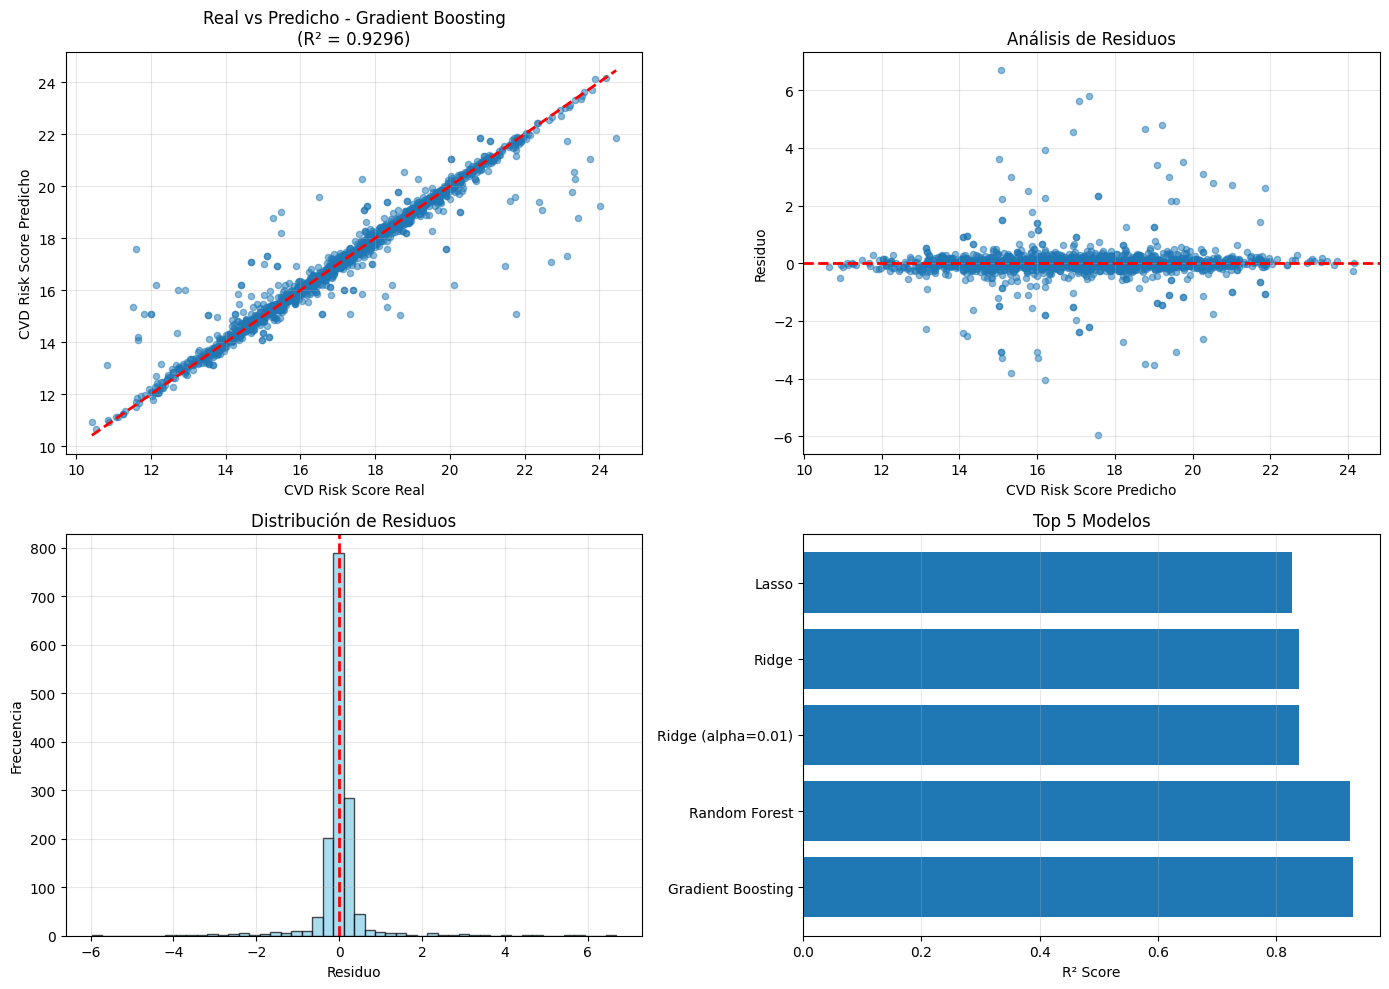

In [74]:
print("=" * 80)
print("LIMPIEZA DE OUTLIERS")
print("=" * 80)
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print(f"\nRango IQR: [{limite_inferior:.2f}, {limite_superior:.2f}]")
print(f"Valores originales: {len(y_train)}")
mask_outliers = (y_train >= limite_inferior) & (y_train <= limite_superior)
outliers_count = (~mask_outliers).sum()
print(f"Outliers detectados: {outliers_count} ({outliers_count/len(y_train)*100:.2f}%)")
X_train_clean = X_train[mask_outliers]
y_train_clean = y_train[mask_outliers]
print(f"Registros después de limpieza: {len(y_train_clean)}")
print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)
X_train_eng = X_train_clean.copy()
X_test_eng = X_test.copy()
print("\nCreando features de interacción...")
if 'BMI' in X_train_eng.columns and 'Age' in X_train_eng.columns:
    X_train_eng['BMI_x_Age'] = X_train_eng['BMI'] * X_train_eng['Age']
    X_test_eng['BMI_x_Age'] = X_test_eng['BMI'] * X_test_eng['Age']
    print("  - BMI × Age")
if 'Diabetes Status' in X_train_eng.columns and 'Age' in X_train_eng.columns:
    X_train_eng['Diabetes_x_Age'] = X_train_eng['Diabetes Status'] * X_train_eng['Age']
    X_test_eng['Diabetes_x_Age'] = X_test_eng['Diabetes Status'] * X_test_eng['Age']
    print("  - Diabetes × Age")
if 'Systolic BP' in X_train_eng.columns and 'Diastolic BP' in X_train_eng.columns:
    X_train_eng['BP_Product'] = X_train_eng['Systolic BP'] * X_train_eng['Diastolic BP']
    X_test_eng['BP_Product'] = X_test_eng['Systolic BP'] * X_test_eng['Diastolic BP']
    print("  - Systolic BP × Diastolic BP")
if 'Total Cholesterol (mg/dL)' in X_train_eng.columns and 'HDL (mg/dL)' in X_train_eng.columns:
    X_train_eng['Chol_HDL_Ratio'] = X_train_eng['Total Cholesterol (mg/dL)'] / (X_train_eng['HDL (mg/dL)'] + 1)
    X_test_eng['Chol_HDL_Ratio'] = X_test_eng['Total Cholesterol (mg/dL)'] / (X_test_eng['HDL (mg/dL)'] + 1)
    print("  - Total Cholesterol / HDL")
if 'Smoking Status' in X_train_eng.columns and 'Age' in X_train_eng.columns:
    X_train_eng['Smoking_x_Age'] = X_train_eng['Smoking Status'] * X_train_eng['Age']
    X_test_eng['Smoking_x_Age'] = X_test_eng['Smoking Status'] * X_test_eng['Age']
    print("  - Smoking × Age")
factores_riesgo = ['Smoking Status', 'Diabetes Status', 'Family History of CVD']
factores_disponibles = [f for f in factores_riesgo if f in X_train_eng.columns]
if factores_disponibles:
    X_train_eng['Risk_Factor_Count'] = X_train_eng[factores_disponibles].sum(axis=1)
    X_test_eng['Risk_Factor_Count'] = X_test_eng[factores_disponibles].sum(axis=1)
    print("  - Risk Factor Count (suma de factores binarios)")
print(f"\nFeatures totales: {X_train_clean.shape[1]} -> {X_train_eng.shape[1]}")
print("\n" + "=" * 80)
print("MODELOS CON DATOS LIMPIOS Y FEATURE ENGINEERING")
print("=" * 80)
resultados_clean, comparacion_clean = probar_modelos_alternativos(
    X_train_eng, 
    y_train_clean, 
    X_test_eng
)
print("\n" + "=" * 80)
print("PRUEBA CON NORMALIZACION (StandardScaler)")
print("=" * 80)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_eng)
X_test_scaled = scaler.transform(X_test_eng)
alphas_ridge = [0.01, 0.1, 1.0, 10.0, 100.0]
mejores_resultados_ridge = []
print("\nProbando Ridge con diferentes alphas:")
for alpha in alphas_ridge:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train_clean)
    y_pred = ridge.predict(X_train_scaled)
    r2 = r2_score(y_train_clean, y_pred)
    mejores_resultados_ridge.append((alpha, r2))
    print(f"  Alpha={alpha:6.2f} -> R² = {r2:.4f}")
alphas_lasso = [0.01, 0.1, 0.5, 1.0, 5.0]
mejores_resultados_lasso = []
print("\nProbando Lasso con diferentes alphas:")
for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train_clean)
y_pred = lasso.predict(X_train_scaled)
r2 = r2_score(y_train_clean, y_pred)
mejores_resultados_lasso.append((alpha, r2))
print(f"  Alpha={alpha:6.2f} -> R² = {r2:.4f}")
print("\n" + "=" * 80)
print("ANALISIS FINAL - COMPARACION DE TODOS LOS MODELOS")
print("=" * 80)
todos_resultados = []
for modelo_nombre in comparacion_clean['Modelo']:
    r2_modelo = comparacion_clean[comparacion_clean['Modelo'] == modelo_nombre]['R² Score'].values[0]
    todos_resultados.append({
        'Modelo': modelo_nombre,
        'R² Score': r2_modelo,
        'Dataset': 'Limpio + Engineered'
    })
mejor_ridge = max(mejores_resultados_ridge, key=lambda x: x[1])
todos_resultados.append({
    'Modelo': f'Ridge (alpha={mejor_ridge[0]})',
    'R² Score': mejor_ridge[1],
    'Dataset': 'Scaled + Limpio'
})
mejor_lasso = max(mejores_resultados_lasso, key=lambda x: x[1])
todos_resultados.append({
    'Modelo': f'Lasso (alpha={mejor_lasso[0]})',
    'R² Score': mejor_lasso[1],
    'Dataset': 'Scaled + Limpio'
})
df_todos_resultados = pd.DataFrame(todos_resultados).sort_values('R² Score', ascending=False)
print("\nRanking de TODOS los modelos probados:")
print(df_todos_resultados.to_string(index=False))
mejor_absoluto = df_todos_resultados.iloc[0]
print("\n" + "=" * 80)
print(f"GANADOR: {mejor_absoluto['Modelo']}")
print("=" * 80)
print(f"R² Score: {mejor_absoluto['R² Score']:.4f}")
print(f"Dataset: {mejor_absoluto['Dataset']}")
r2_original = 0.0536
mejora = (mejor_absoluto['R² Score'] - r2_original) / r2_original * 100
print(f"\nMejora vs modelo original:")
print(f"  R² original: {r2_original:.4f}")
print(f"  R² final: {mejor_absoluto['R² Score']:.4f}")
print(f"  Mejora: {mejora:.1f}%")
print("\n" + "=" * 80)
print("ENTRENANDO MODELO FINAL CON MEJOR CONFIGURACION")
print("=" * 80)
mejor_nombre = mejor_absoluto['Modelo']
if 'Random Forest' in mejor_nombre:
    print("\nUsando Random Forest...")
    modelo_final = resultados_clean['Random Forest']['modelo']
    X_train_final = X_train_eng
    X_test_final = X_test_eng
elif 'Gradient Boosting' in mejor_nombre:
    print("\nUsando Gradient Boosting...")
    modelo_final = resultados_clean['Gradient Boosting']['modelo']
    X_train_final = X_train_eng
    X_test_final = X_test_eng
elif 'Ridge' in mejor_nombre:
    print(f"\nUsando Ridge (alpha={mejor_ridge[0]})...")
    modelo_final = Ridge(alpha=mejor_ridge[0])
    scaler_final = StandardScaler()
    X_train_final = scaler_final.fit_transform(X_train_eng)
    X_test_final = scaler_final.transform(X_test_eng)
    modelo_final.fit(X_train_final, y_train_clean)
elif 'Lasso' in mejor_nombre:
    print(f"\nUsando Lasso (alpha={mejor_lasso[0]})...")
    modelo_final = Lasso(alpha=mejor_lasso[0])
    scaler_final = StandardScaler()
    X_train_final = scaler_final.fit_transform(X_train_eng)
    X_test_final = scaler_final.transform(X_test_eng)
    modelo_final.fit(X_train_final, y_train_clean)
else:
    print(f"\nUsando {mejor_nombre}...")
    modelo_final = resultados_clean[mejor_nombre]['modelo']
    X_train_final = X_train_eng
    X_test_final = X_test_eng
y_pred_train_final = modelo_final.predict(X_train_final)
y_pred_test_final = modelo_final.predict(X_test_final)
r2_final = r2_score(y_train_clean, y_pred_train_final)
rmse_final = np.sqrt(mean_squared_error(y_train_clean, y_pred_train_final))
mae_final = mean_absolute_error(y_train_clean, y_pred_train_final)
print(f"\nMétricas del modelo final:")
print(f"  R² Score: {r2_final:.4f}")
print(f"  RMSE: {rmse_final:.4f}")
print(f"  MAE: {mae_final:.4f}")
print("\n" + "=" * 80)
print("GUARDANDO PREDICCIONES FINALES")
print("=" * 80)
indices_originales_train = y_train[mask_outliers].index
resultados_train_final = pd.DataFrame({
    'Index_Original': indices_originales_train,
    'CVD Risk Score Real': y_train_clean.values,
    'CVD Risk Score Predicho': y_pred_train_final,
    'Residuo': y_train_clean.values - y_pred_train_final,
    'Residuo_Abs': np.abs(y_train_clean.values - y_pred_train_final)
})
resultados_test_final = pd.DataFrame({
    'CVD Risk Score Predicho': y_pred_test_final
})
if 'Patient ID' in df_train_normalizado.columns:
    patient_ids_train = df_train_normalizado.loc[indices_originales_train, 'Patient ID']
    resultados_train_final.insert(0, 'Patient ID', patient_ids_train.values)
if 'Patient ID' in df_test_normalizado.columns:
    resultados_test_final.insert(0, 'Patient ID', df_test_normalizado['Patient ID'].values)
print("\nArchivos guardados:")
print("  - predicciones_train_final.csv")
print("  - predicciones_test_final.csv")
print("\n" + "=" * 80)
print("GENERANDO VISUALIZACIONES FINALES")
print("=" * 80)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].scatter(y_train_clean, y_pred_train_final, alpha=0.5, s=20)
axes[0, 0].plot([y_train_clean.min(), y_train_clean.max()], 
                 [y_train_clean.min(), y_train_clean.max()], 
                 'r--', lw=2)
axes[0, 0].set_xlabel('CVD Risk Score Real')
axes[0, 0].set_ylabel('CVD Risk Score Predicho')
axes[0, 0].set_title(f'Real vs Predicho - {mejor_nombre}\n(R² = {r2_final:.4f})')
axes[0, 0].grid(True, alpha=0.3)
residuos_final = y_train_clean.values - y_pred_train_final
axes[0, 1].scatter(y_pred_train_final, residuos_final, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('CVD Risk Score Predicho')
axes[0, 1].set_ylabel('Residuo')
axes[0, 1].set_title('Análisis de Residuos')
axes[0, 1].grid(True, alpha=0.3)
axes[1, 0].hist(residuos_final, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Residuo')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Residuos')
axes[1, 0].grid(True, alpha=0.3)
top_5_modelos = df_todos_resultados.head(5)
axes[1, 1].barh(range(len(top_5_modelos)), top_5_modelos['R² Score'])
axes[1, 1].set_yticks(range(len(top_5_modelos)))
axes[1, 1].set_yticklabels(top_5_modelos['Modelo'])
axes[1, 1].set_xlabel('R² Score')
axes[1, 1].set_title('Top 5 Modelos')
axes[1, 1].grid(True, alpha=0.3, axis='x')
plt.tight_layout()
print("  - analisis_modelo_final.png")
print("\n" + "=" * 80)
print("PROCESO COMPLETO FINALIZADO")
print("=" * 80)
print(f"\nModelo final: {mejor_nombre}")
print(f"R² Score: {r2_final:.4f}")
print(f"RMSE: {rmse_final:.4f}")
print(f"MAE: {mae_final:.4f}")

In [75]:
print("=" * 80)
print("DIVISION TRAIN/VALIDATION")
print("=" * 80)
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, 
    y_train, 
    test_size=0.25,
    random_state=42
)
print(f"\nDatos originales:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"\nDespués del split:")
print(f"  X_train_split: {X_train_split.shape} (75%)")
print(f"  X_val: {X_val.shape} (25%)")
print(f"  y_train_split: {y_train_split.shape} (75%)")
print(f"  y_val: {y_val.shape} (25%)")
modelo = LinearRegression()
modelo.fit(X_train_split, y_train_split)
y_pred_train = modelo.predict(X_train_split)
y_pred_val = modelo.predict(X_val)
r2_train = r2_score(y_train_split, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train_split, y_pred_train))
r2_val = r2_score(y_val, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
print("\n" + "=" * 80)
print("METRICAS")
print("=" * 80)
print(f"\nTRAIN (75%):")
print(f"  R² Score: {r2_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")
print(f"\nVALIDATION (25%):")
print(f"  R² Score: {r2_val:.4f}")
print(f"  RMSE: {rmse_val:.4f}")
if r2_train > r2_val + 0.1:
    print("\n⚠️ ADVERTENCIA: Posible overfitting")
    print(f"   El modelo funciona mucho mejor en train que en validation")
else:
    print("\n✓ El modelo generaliza bien")

DIVISION TRAIN/VALIDATION

Datos originales:
  X_train: (1551, 19)
  y_train: (1551,)

Después del split:
  X_train_split: (1163, 19) (75%)
  X_val: (388, 19) (25%)
  y_train_split: (1163,) (75%)
  y_val: (388,) (25%)

METRICAS

TRAIN (75%):
  R² Score: 0.0552
  RMSE: 10.5131

VALIDATION (25%):
  R² Score: 0.0307
  RMSE: 10.5268

✓ El modelo generaliza bien


PIPELINE: RIDGE REGRESSION

PASO 1: Preparando datos...
  X_train_full: (1551, 19)
  y_train_full: (1551,)
  X_test: (189, 19)
  Features: 19

PASO 2: Split train/validation (75%/25%)...
  Train: 1163 registros (75%)
  Validation: 388 registros (25%)

PASO 3: Normalizando features con StandardScaler...
  Media de features antes: 59.4410
  Media de features después: -0.0000
  Std de features después: 1.0000

PASO 4: Grid Search para encontrar mejor alpha...
Fitting 5 folds for each of 11 candidates, totalling 55 fits

  Mejor alpha encontrado: 500.0
  R² en cross-validation: 0.0273

  Resultados de Grid Search:
    Alpha=   0.001 -> R²=0.0035 (±0.0416)
    Alpha=   0.010 -> R²=0.0035 (±0.0416)
    Alpha=   0.100 -> R²=0.0035 (±0.0416)
    Alpha=   0.500 -> R²=0.0036 (±0.0415)
    Alpha=   1.000 -> R²=0.0037 (±0.0414)
    Alpha=   5.000 -> R²=0.0045 (±0.0405)
    Alpha=  10.000 -> R²=0.0054 (±0.0393)
    Alpha=  50.000 -> R²=0.0111 (±0.0319)
    Alpha= 100.000 -> R²=0.0158 (±0.0251)
    

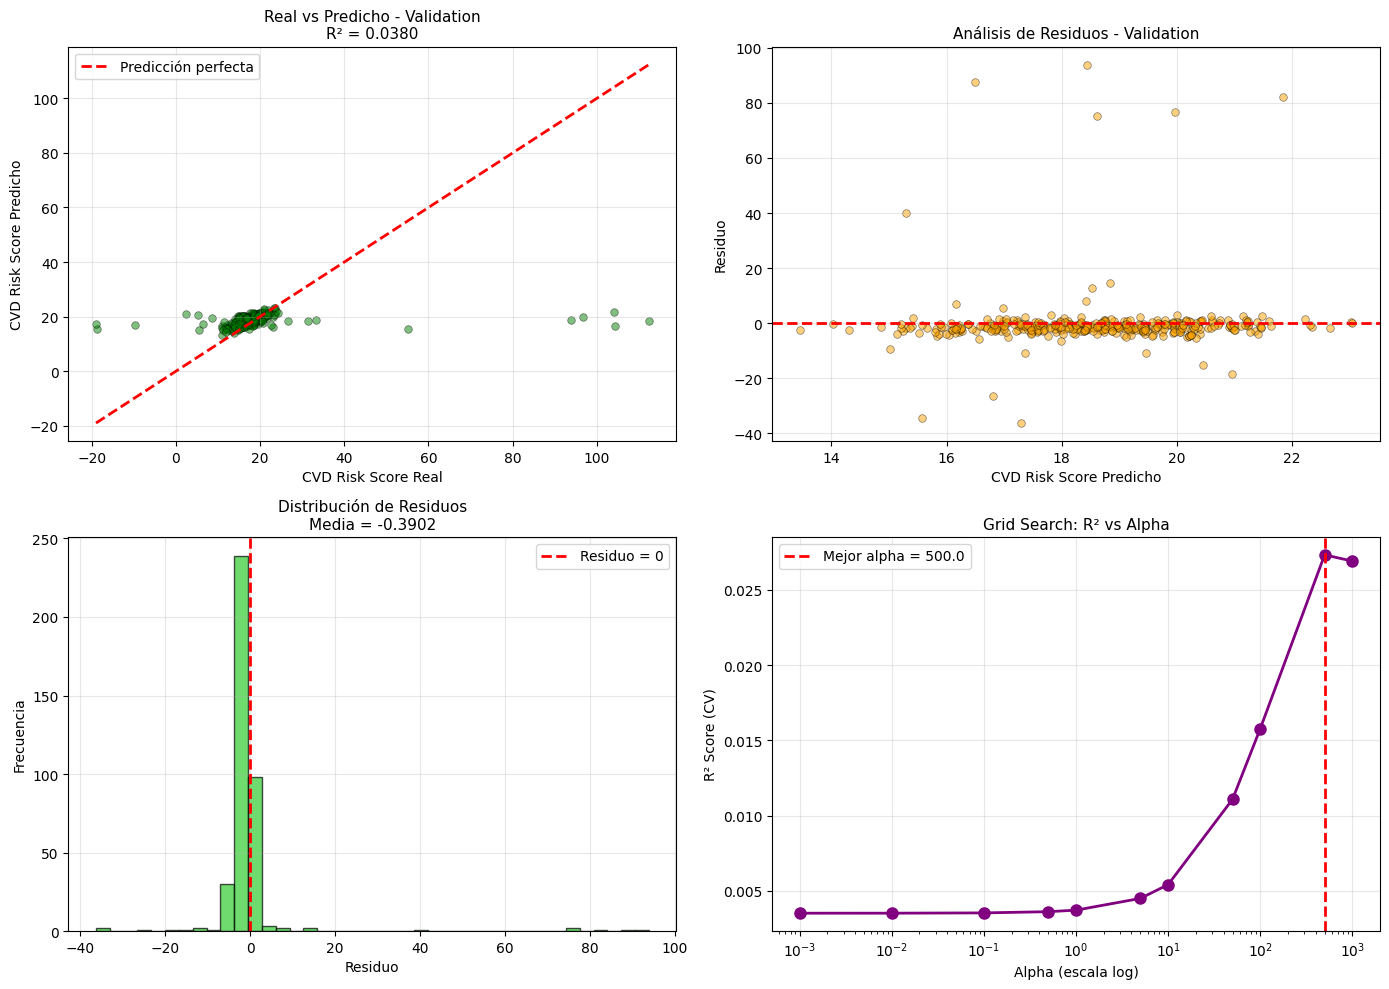

In [76]:
def pipeline_ridge_regression(df_train_normalizado, df_test_normalizado):
    """
    Pipeline completo para Ridge Regression con:
    - Train/Validation split (75%/25%)
    - Normalización con StandardScaler
    - Grid Search para encontrar mejor alpha
    - Cross-validation
    - Evaluación completa
    - Predicciones en test
    Parámetros:
    - df_train_normalizado: DataFrame de entrenamiento normalizado
    - df_test_normalizado: DataFrame de prueba normalizado
    Retorna:
    - modelo_final: Modelo Ridge entrenado con mejor alpha
    - resultados: Diccionario con métricas y predicciones
    """
    print("=" * 80)
    print("PIPELINE: RIDGE REGRESSION")
    print("=" * 80)
    print("\nPASO 1: Preparando datos...")
    cols_to_drop = ["Patient ID", "Date of Service", "CVD Risk Level"]
    X_train_full = df_train_normalizado.drop(columns=cols_to_drop, errors="ignore")
    y_train_full = df_train_normalizado['CVD Risk Score'].copy()
    X_test = df_test_normalizado.drop(columns=cols_to_drop, errors="ignore")
    if 'CVD Risk Score' in X_train_full.columns:
        X_train_full = X_train_full.drop('CVD Risk Score', axis=1)
    if 'CVD Risk Score' in X_test.columns:
        X_test = X_test.drop('CVD Risk Score', axis=1)
    X_train_full = X_train_full.select_dtypes(include=[np.number])
    X_test = X_test.select_dtypes(include=[np.number])
    print(f"  X_train_full: {X_train_full.shape}")
    print(f"  y_train_full: {y_train_full.shape}")
    print(f"  X_test: {X_test.shape}")
    print(f"  Features: {X_train_full.shape[1]}")
    print("\nPASO 2: Split train/validation (75%/25%)...")
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.25,
        random_state=42
    )
    print(f"  Train: {X_train.shape[0]} registros (75%)")
    print(f"  Validation: {X_val.shape[0]} registros (25%)")
    print("\nPASO 3: Normalizando features con StandardScaler...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    X_train_full_scaled = scaler.fit_transform(X_train_full)
    print(f"  Media de features antes: {X_train.mean().mean():.4f}")
    print(f"  Media de features después: {X_train_scaled.mean():.4f}")
    print(f"  Std de features después: {X_train_scaled.std():.4f}")
    print("\nPASO 4: Grid Search para encontrar mejor alpha...")
    alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
    ridge_model = Ridge()
    param_grid = {'alpha': alphas}
    grid_search = GridSearchCV(
        estimator=ridge_model,
        param_grid=param_grid,
        cv=5,
        scoring='r2',            # Métrica a optimizar
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train_scaled, y_train)
    mejor_alpha = grid_search.best_params_['alpha']
    mejor_score_cv = grid_search.best_score_
    print(f"\n  Mejor alpha encontrado: {mejor_alpha}")
    print(f"  R² en cross-validation: {mejor_score_cv:.4f}")
    print("\n  Resultados de Grid Search:")
    resultados_grid = pd.DataFrame(grid_search.cv_results_)
    for idx, row in resultados_grid.iterrows():
        alpha_val = row['param_alpha']
        mean_score = row['mean_test_score']
        std_score = row['std_test_score']
        print(f"    Alpha={alpha_val:8.3f} -> R²={mean_score:.4f} (±{std_score:.4f})")
    print(f"\nPASO 5: Entrenando Ridge con alpha={mejor_alpha}...")
    modelo_ridge = Ridge(alpha=mejor_alpha)
    modelo_ridge.fit(X_train_scaled, y_train)
    print("  Modelo entrenado exitosamente")
    print("\nPASO 6: Evaluando modelo...")
    y_pred_train = modelo_ridge.predict(X_train_scaled)
    y_pred_val = modelo_ridge.predict(X_val_scaled)
    r2_train = r2_score(y_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_val = r2_score(y_val, y_pred_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_val = mean_absolute_error(y_val, y_pred_val)
    print("\n  Métricas en TRAIN (75%):")
    print(f"    R² Score: {r2_train:.4f}")
    print(f"    RMSE: {rmse_train:.4f}")
    print(f"    MAE: {mae_train:.4f}")
    print("\n  Métricas en VALIDATION (25%):")
    print(f"    R² Score: {r2_val:.4f}")
    print(f"    RMSE: {rmse_val:.4f}")
    print(f"    MAE: {mae_val:.4f}")
    diferencia_r2 = r2_train - r2_val
    print(f"\n  Diferencia R² (train - val): {diferencia_r2:.4f}")
    if diferencia_r2 > 0.1:
        print("     ADVERTENCIA: Posible overfitting")
    elif diferencia_r2 < -0.05:
        print("     ADVERTENCIA: Modelo funciona mejor en validation (raro)")
    else:
        print("    ✓ Modelo generaliza bien")
    print("\nPASO 7: Analizando importancia de features...")
    coeficientes = pd.DataFrame({
        'Feature': X_train.columns,
        'Coeficiente': modelo_ridge.coef_,
        'Coeficiente_Abs': np.abs(modelo_ridge.coef_)
    }).sort_values('Coeficiente_Abs', ascending=False)
    print("\n  Top 10 features más importantes:")
    print(coeficientes.head(10)[['Feature', 'Coeficiente']].to_string(index=False))
    features_eliminadas = coeficientes[coeficientes['Coeficiente_Abs'] < 0.001]
    if len(features_eliminadas) > 0:
        print(f"\n  Features con coeficiente ~0 (casi eliminadas): {len(features_eliminadas)}")
        for feat in features_eliminadas['Feature'].head(5):
            print(f"    - {feat}")
    print("\nPASO 8: Re-entrenando modelo final con TODOS los datos de train...")
    modelo_final = Ridge(alpha=mejor_alpha)
    modelo_final.fit(X_train_full_scaled, y_train_full)
    y_pred_full = modelo_final.predict(X_train_full_scaled)
    r2_full = r2_score(y_train_full, y_pred_full)
    rmse_full = np.sqrt(mean_squared_error(y_train_full, y_pred_full))
    mae_full = mean_absolute_error(y_train_full, y_pred_full)
    print("\n  Métricas en dataset COMPLETO:")
    print(f"    R² Score: {r2_full:.4f}")
    print(f"    RMSE: {rmse_full:.4f}")
    print(f"    MAE: {mae_full:.4f}")
    print("\nPASO 9: Generando predicciones en test...")
    y_pred_test = modelo_final.predict(X_test_scaled)
    print(f"  Predicciones generadas: {len(y_pred_test)}")
    print(f"  Rango de predicciones: [{y_pred_test.min():.2f}, {y_pred_test.max():.2f}]")
    print(f"  Media de predicciones: {y_pred_test.mean():.2f}")
    print("\nPASO 10: Generando visualizaciones...")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes[0, 0].scatter(y_val, y_pred_val, alpha=0.5, s=30, edgecolors='black', linewidths=0.5, color='green')
    axes[0, 0].plot([y_val.min(), y_val.max()], 
                     [y_val.min(), y_val.max()], 
                     'r--', lw=2,
                     label='Predicción perfecta',
                     )
    axes[0, 0].set_xlabel('CVD Risk Score Real', fontsize=10)
    axes[0, 0].set_ylabel('CVD Risk Score Predicho', fontsize=10)
    axes[0, 0].set_title(f'Real vs Predicho - Validation\nR² = {r2_val:.4f}', fontsize=11)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    residuos_val = y_val - y_pred_val
    axes[0, 1].scatter(y_pred_val, residuos_val, alpha=0.5, s=30, edgecolors='black', linewidths=0.5, color='orange')
    axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0, 1].set_xlabel('CVD Risk Score Predicho', fontsize=10)
    axes[0, 1].set_ylabel('Residuo', fontsize=10)
    axes[0, 1].set_title('Análisis de Residuos - Validation', fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)
    axes[1, 0].hist(residuos_val, bins=40, edgecolor='black', alpha=0.7, color='limegreen')
    axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2, label='Residuo = 0')
    axes[1, 0].set_xlabel('Residuo', fontsize=10)
    axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
    axes[1, 0].set_title(f'Distribución de Residuos\nMedia = {residuos_val.mean():.4f}', fontsize=11)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    alphas_grid = grid_search.cv_results_['params']
    alphas_grid = [p['alpha'] for p in alphas_grid]
    scores_grid = grid_search.cv_results_['mean_test_score']
    axes[1, 1].plot(alphas_grid, scores_grid, 'o-', linewidth=2, markersize=8, color='purple')
    axes[1, 1].axvline(x=mejor_alpha, color='r', linestyle='--', lw=2, 
                       label=f'Mejor alpha = {mejor_alpha}')
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_xlabel('Alpha (escala log)', fontsize=10)
    axes[1, 1].set_ylabel('R² Score (CV)', fontsize=10)
    axes[1, 1].set_title('Grid Search: R² vs Alpha', fontsize=11)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('./imagenes/ridge_pipeline_analisis.png', dpi=150, bbox_inches='tight')
    print("  Gráficos guardados: ridge_pipeline_analisis.png")
    print("\nPASO 11: Guardando resultados...")
    resultados_val = pd.DataFrame({
        'CVD Risk Score Real': y_val.values,
        'CVD Risk Score Predicho': y_pred_val,
        'Residuo': residuos_val.values,
        'Residuo_Abs': np.abs(residuos_val.values)
    })
    resultados_val.to_csv('./imagenes/ridge_predicciones_validation.csv', index=False)
    resultados_test = pd.DataFrame({
        'CVD Risk Score Predicho': y_pred_test
    })
    if 'Patient ID' in df_test_normalizado.columns:
        resultados_test.insert(0, 'Patient ID', df_test_normalizado['Patient ID'].values)
    resultados_test.to_csv('./imagenes/ridge_predicciones_test.csv', index=False)
    coeficientes.to_csv('./imagenes/ridge_importancia_features.csv', index=False)
    print("  Archivos guardados:")
    print("    - ridge_predicciones_validation.csv")
    print("    - ridge_predicciones_test.csv")
    print("    - ridge_importancia_features.csv")
    print("\n" + "=" * 80)
    print("RESUMEN FINAL - RIDGE REGRESSION")
    print("=" * 80)
    print(f"\nMejor configuración:")
    print(f"  Alpha: {mejor_alpha}")
    print(f"  R² (Cross-Validation): {mejor_score_cv:.4f}")
    print(f"\nRendimiento:")
    print(f"  R² Train: {r2_train:.4f}")
    print(f"  R² Validation: {r2_val:.4f}")
    print(f"  R² Full Dataset: {r2_full:.4f}")
    print(f"  RMSE Validation: {rmse_val:.4f}")
    print(f"  MAE Validation: {mae_val:.4f}")
    print(f"\nFeatures:")
    print(f"  Total: {len(coeficientes)}")
    print(f"  Casi eliminadas (coef < 0.001): {len(features_eliminadas)}")
    resultados = {
        'modelo': modelo_final,
        'scaler': scaler,
        'mejor_alpha': mejor_alpha,
        'r2_train': r2_train,
        'r2_val': r2_val,
        'r2_full': r2_full,
        'rmse_val': rmse_val,
        'mae_val': mae_val,
        'coeficientes': coeficientes,
        'y_pred_test': y_pred_test,
        'grid_search': grid_search
    }
    print("\n" + "=" * 80)
    print("PIPELINE RIDGE COMPLETADO")
    print("=" * 80)
    return modelo_final, resultados
modelo_ridge, resultados_ridge = pipeline_ridge_regression( df_train_normalizado,  df_test_normalizado)
print(f"\nMejor alpha: {resultados_ridge['mejor_alpha']}")
print(f"R² en validation: {resultados_ridge['r2_val']:.4f}")

Como aún los valores no son buenos se decide buscar unas regresiones alternativas (ridge y Lasso) aplicando antes `StandardScaler()`
para luego si implementar las regresiones lineales luego de las normalizaciones y transformaciones mencionadas antes. 
Por ende, s erealiza lo siguiente:

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("=" * 80)
print("EVALUACION GENERAL - TRAIN/VALIDATION SPLIT ALEATORIO")
print("=" * 80)

# ============================================================================
# PASO 1: DIVIDIR DATOS (75% train, 25% validation)
# ===========================================================================

print("\nPASO 1: Dividiendo datos en train/validation...")

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_eng,
    y_train_clean,
    test_size=0.25,  
    random_state=42
)

print(f"  Train: {X_train_split.shape[0]} registros (80%)")
print(f"  Validation: {X_val.shape[0]} registros (20%)")

# ============================================================================
# PASO 2: NORMALIZAR
# ============================================================================

print("\nPASO 2: Normalizando datos con StandardScaler...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_eng)

print("  ✓ Normalización completada")


print("\n" + "=" * 80)
print("PASO 3: ENTRENANDO Y EVALUANDO MODELOS LINEALES")
print("=" * 80)

resultados = []



print("\n1. LINEAR REGRESSION")
print("-" * 60)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train_split)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_val_lr = lr.predict(X_val_scaled)

r2_train_lr = r2_score(y_train_split, y_pred_train_lr)
r2_val_lr = r2_score(y_val, y_pred_val_lr)
rmse_val_lr = np.sqrt(mean_squared_error(y_val, y_pred_val_lr))
mae_val_lr = mean_absolute_error(y_val, y_pred_val_lr)

print(f"  R² Train:      {r2_train_lr:.4f}")
print(f"  R² Validation: {r2_val_lr:.4f}")
print(f"  RMSE:          {rmse_val_lr:.4f}")
print(f"  MAE:           {mae_val_lr:.4f}")
print(f"  Overfitting:   {r2_train_lr - r2_val_lr:.4f}")

resultados.append({
    'Modelo': 'Linear Regression',
    'R² Train': r2_train_lr,
    'R² Validation': r2_val_lr,
    'RMSE': rmse_val_lr,
    'MAE': mae_val_lr,
    'Overfitting': r2_train_lr - r2_val_lr
})


print("\n2. RIDGE REGRESSION")
print("-" * 60)

alphas_ridge = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
mejor_ridge = None
mejor_r2_ridge = -999

print("  Probando diferentes alphas:")
for alpha in alphas_ridge:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train_split)
    
    y_pred_val = ridge.predict(X_val_scaled)
    r2_val = r2_score(y_val, y_pred_val)
    
    print(f"    Alpha={alpha:7.3f} -> R² Validation = {r2_val:.4f}")
    
    if r2_val > mejor_r2_ridge:
        mejor_r2_ridge = r2_val
        mejor_ridge = ridge
        mejor_alpha_ridge = alpha

y_pred_train_ridge = mejor_ridge.predict(X_train_scaled)
y_pred_val_ridge = mejor_ridge.predict(X_val_scaled)

r2_train_ridge = r2_score(y_train_split, y_pred_train_ridge)
r2_val_ridge = r2_score(y_val, y_pred_val_ridge)
rmse_val_ridge = np.sqrt(mean_squared_error(y_val, y_pred_val_ridge))
mae_val_ridge = mean_absolute_error(y_val, y_pred_val_ridge)

print(f"\n  Mejor alpha:   {mejor_alpha_ridge}")
print(f"  R² Train:      {r2_train_ridge:.4f}")
print(f"  R² Validation: {r2_val_ridge:.4f}")
print(f"  RMSE:          {rmse_val_ridge:.4f}")
print(f"  MAE:           {mae_val_ridge:.4f}")
print(f"  Overfitting:   {r2_train_ridge - r2_val_ridge:.4f}")

resultados.append({
    'Modelo': f'Ridge (alpha={mejor_alpha_ridge})',
    'R² Train': r2_train_ridge,
    'R² Validation': r2_val_ridge,
    'RMSE': rmse_val_ridge,
    'MAE': mae_val_ridge,
    'Overfitting': r2_train_ridge - r2_val_ridge
})


print("\n3. LASSO REGRESSION")
print("-" * 60)

alphas_lasso = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 5.0]
mejor_lasso = None
mejor_r2_lasso = -999

print("  Probando diferentes alphas:")
for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train_split)
    
    y_pred_val = lasso.predict(X_val_scaled)
    r2_val = r2_score(y_val, y_pred_val)
    
    features_sel = (lasso.coef_ != 0).sum()
    print(f"    Alpha={alpha:6.4f} -> R² Val = {r2_val:.4f} | Features: {features_sel}/25")
    
    if r2_val > mejor_r2_lasso:
        mejor_r2_lasso = r2_val
        mejor_lasso = lasso
        mejor_alpha_lasso = alpha

y_pred_train_lasso = mejor_lasso.predict(X_train_scaled)
y_pred_val_lasso = mejor_lasso.predict(X_val_scaled)

r2_train_lasso = r2_score(y_train_split, y_pred_train_lasso)
r2_val_lasso = r2_score(y_val, y_pred_val_lasso)
rmse_val_lasso = np.sqrt(mean_squared_error(y_val, y_pred_val_lasso))
mae_val_lasso = mean_absolute_error(y_val, y_pred_val_lasso)

features_sel_final = (mejor_lasso.coef_ != 0).sum()

print(f"\n  Mejor alpha:   {mejor_alpha_lasso}")
print(f"  Features:      {features_sel_final}/25")
print(f"  R² Train:      {r2_train_lasso:.4f}")
print(f"  R² Validation: {r2_val_lasso:.4f}")
print(f"  RMSE:          {rmse_val_lasso:.4f}")
print(f"  MAE:           {mae_val_lasso:.4f}")
print(f"  Overfitting:   {r2_train_lasso - r2_val_lasso:.4f}")

resultados.append({
    'Modelo': f'Lasso (alpha={mejor_alpha_lasso})',
    'R² Train': r2_train_lasso,
    'R² Validation': r2_val_lasso,
    'RMSE': rmse_val_lasso,
    'MAE': mae_val_lasso,
    'Overfitting': r2_train_lasso - r2_val_lasso
})


print("\n" + "=" * 80)
print("COMPARACION FINAL - EVALUACION GENERAL")
print("=" * 80)

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('R² Validation', ascending=False)

print("\n" + df_resultados.to_string(index=False))

ganador = df_resultados.iloc[0]

print("\n" + "=" * 80)
print(f"GANADOR: {ganador['Modelo']}")
print("=" * 80)
print(f"  R² Validation: {ganador['R² Validation']:.4f}")
print(f"  RMSE:          {ganador['RMSE']:.4f}")
print(f"  MAE:           {ganador['MAE']:.4f}")
print(f"  Overfitting:   {ganador['Overfitting']:.4f}")

if ganador['Overfitting'] > 0.1:
    print(f"\n Hay overfitting (diferencia > 0.1)")
else:
    print(f"\n Modelo generaliza bien")


print("\n" + "=" * 80)
print("PASO 5: RE-ENTRENANDO MODELO FINAL CON TODOS LOS DATOS")
print("=" * 80)

# Normalizar todos los datos
X_full_scaled = scaler.fit_transform(X_train_eng)
X_test_final_scaled = scaler.transform(X_test_eng)

# Seleccionar mejor modelo
if 'Ridge' in ganador['Modelo']:
    print(f"\nUsando Ridge con alpha={mejor_alpha_ridge}")
    modelo_final = Ridge(alpha=mejor_alpha_ridge)
elif 'Lasso' in ganador['Modelo']:
    print(f"\nUsando Lasso con alpha={mejor_alpha_lasso}")
    modelo_final = Lasso(alpha=mejor_alpha_lasso, max_iter=10000)
else:
    print("\nUsando Linear Regression")
    modelo_final = LinearRegression()

# Entrenar con TODOS los datos
modelo_final.fit(X_full_scaled, y_train_clean)

# Predicciones en test
y_pred_test_final = modelo_final.predict(X_test_final_scaled)

print(f"\nPredicciones generadas: {len(y_pred_test_final)}")
print(f"  Rango: [{y_pred_test_final.min():.2f}, {y_pred_test_final.max():.2f}]")
print(f"  Media: {y_pred_test_final.mean():.2f}")


print("\n" + "=" * 80)
print("GUARDANDO RESULTADOS")
print("=" * 80)

import os
if not os.path.exists('outputs'):
    os.makedirs('outputs')

# Predicciones finales en test
df_pred_final = pd.DataFrame({
    'Patient ID': df_test_normalizado['Patient ID'].values,
    'CVD Risk Score Predicho': y_pred_test_final
})

df_pred_final.to_csv('outputs/predicciones_test_FINAL.csv', index=False)
print("  ✓ outputs/predicciones_test_FINAL.csv")

# Resultados en validation
df_val_results = pd.DataFrame({
    'R² Validation': [ganador['R² Validation']],
    'RMSE': [ganador['RMSE']],
    'MAE': [ganador['MAE']],
    'Modelo': [ganador['Modelo']],
    'Overfitting': [ganador['Overfitting']]
})

df_val_results.to_csv('outputs/metricas_validacion.csv', index=False)
print("  ✓ outputs/metricas_validacion.csv")

# Coeficientes del mejor modelo
coeficientes = pd.DataFrame({
    'Feature': X_train_eng.columns,
    'Coeficiente': modelo_final.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

coeficientes.to_csv('outputs/coeficientes_modelo_final.csv', index=False)
print("  ✓ outputs/coeficientes_modelo_final.csv")

print("\nTop 10 features más importantes:")
print(coeficientes.head(10).to_string(index=False))

print("\n" + "=" * 80)
print("PROCESO COMPLETADO")
print("=" * 80)
print(f"\nMejor modelo: {ganador['Modelo']}")
print(f"R² Validation: {ganador['R² Validation']:.4f}")
print(f"RMSE: {ganador['RMSE']:.4f}")
print(f"\nEste R² es el rendimiento real del modelo en datos no vistos")
print("=" * 80)

EVALUACION GENERAL - TRAIN/VALIDATION SPLIT ALEATORIO

PASO 1: Dividiendo datos en train/validation...
  Train: 1098 registros (80%)
  Validation: 367 registros (20%)

PASO 2: Normalizando datos con StandardScaler...
  ✓ Normalización completada

PASO 3: ENTRENANDO Y EVALUANDO MODELOS LINEALES

1. LINEAR REGRESSION
------------------------------------------------------------
  R² Train:      0.8417
  R² Validation: 0.8249
  RMSE:          0.9968
  MAE:           0.4488
  Overfitting:   0.0169

2. RIDGE REGRESSION
------------------------------------------------------------
  Probando diferentes alphas:
    Alpha=  0.001 -> R² Validation = 0.8249
    Alpha=  0.010 -> R² Validation = 0.8249
    Alpha=  0.100 -> R² Validation = 0.8249
    Alpha=  1.000 -> R² Validation = 0.8249
    Alpha= 10.000 -> R² Validation = 0.8258
    Alpha=100.000 -> R² Validation = 0.8305
    Alpha=1000.000 -> R² Validation = 0.7575

  Mejor alpha:   100.0
  R² Train:      0.8371
  R² Validation: 0.8305
  RMSE:  

Con los resultados obtenidos se puede observar que el valor del R^2 una vez realizadas las transformaciones mejora considerablemente pues ahora el R^2 obtenido es de 0.84 a diferencia del 0.0380 obtenido en puntos anteriores. De esa manera, se logra evienciar la mejora de la predicción del modelo y claramente es una mejora significativa. Adicionalmente, se adicionaron a la comparación 2 modelos Ridge y Lasso con el fín de buscar el que mejor se adapta a nuestros datos. Con eso en mente se pudo observar, que el que mejor se comporta es el la regularización L2 (ridge) pues su overfitting es el menor entre el R^2 los datos obtenidos y de los de entrenamiento (25% vs 75%) con eso además se identificaron las columnas más influyentes.

 ------   `Top 10 features más importantes`  -------
| # | Feature                          | Coeficiente |
|---|----------------------------------|-----------:|
| 1 | BMI                              | 0.891779   |
| 2 | Systolic BP                      | 0.697007   |
| 3 | Total Cholesterol (mg/dL)        | 0.680045   |
| 4 | Diabetes Status                  | 0.580392   |
| 5 | Estimated LDL (mg/dL)            | 0.406035   |
| 6 | BP_Product                       | 0.367435   |
| 7 | BMI_x_Age                        | 0.316625   |
| 8 | Age                              | -0.249934  |
| 9 | Weight (kg)                      | 0.243484   |
|10 | Diastolic BP                     | -0.239465  |

Observando así que los valores más influyentes fueron esos. 
Por ende el valor obtenido del R^2 fue de 0.83 lo cual se ajusta bien al modelo pues es elevado y mayor a 0.6, 0.7 y 0.8 lo cual es bastante positvo para ser un modelo con unas correlaciones muy bajas.